In [64]:
import pandas as pd
import glob
import os

files = glob.glob(r"F:\cgm-Analyzer\data\*.csv")

dataframes = []

for file in files:
    temp = pd.read_csv(file, sep=";")
    
    patient_id = os.path.basename(file).replace(".csv", "")
    temp["patient_id"] = patient_id
    
    dataframes.append(temp)

df = pd.concat(dataframes, ignore_index=True)

print(df.shape)
print(df.head())

(309392, 9)
                  time  glucose  calories  heart_rate  steps  basal_rate  \
0  2018-06-13T18:40:00    332.0    6.3595   82.322835   34.0    0.091667   
1  2018-06-13T18:45:00    326.0    7.7280   83.740157    0.0    0.091667   
2  2018-06-13T18:50:00    330.0    4.7495   80.525180    0.0    0.091667   
3  2018-06-13T18:55:00    324.0    6.3595   89.129032   20.0    0.091667   
4  2018-06-13T19:00:00    306.0    5.1520   92.495652    0.0    0.075000   

   bolus_volume_delivered  carb_input patient_id  
0                     0.0         0.0  HUPA0001P  
1                     0.0         0.0  HUPA0001P  
2                     0.0         0.0  HUPA0001P  
3                     0.0         0.0  HUPA0001P  
4                     0.0         0.0  HUPA0001P  


In [65]:
print(len(files))
print(files[:3])
print(df.head())
print(df.info())
print(df.isnull().sum())




25
['F:\\cgm-Analyzer\\data\\HUPA0001P.csv', 'F:\\cgm-Analyzer\\data\\HUPA0002P.csv', 'F:\\cgm-Analyzer\\data\\HUPA0003P.csv']
                  time  glucose  calories  heart_rate  steps  basal_rate  \
0  2018-06-13T18:40:00    332.0    6.3595   82.322835   34.0    0.091667   
1  2018-06-13T18:45:00    326.0    7.7280   83.740157    0.0    0.091667   
2  2018-06-13T18:50:00    330.0    4.7495   80.525180    0.0    0.091667   
3  2018-06-13T18:55:00    324.0    6.3595   89.129032   20.0    0.091667   
4  2018-06-13T19:00:00    306.0    5.1520   92.495652    0.0    0.075000   

   bolus_volume_delivered  carb_input patient_id  
0                     0.0         0.0  HUPA0001P  
1                     0.0         0.0  HUPA0001P  
2                     0.0         0.0  HUPA0001P  
3                     0.0         0.0  HUPA0001P  
4                     0.0         0.0  HUPA0001P  
<class 'pandas.DataFrame'>
RangeIndex: 309392 entries, 0 to 309391
Data columns (total 9 columns):
 #   Column

This dataset contains glucose information of 25 patients. There are 309,392 entries with total 9 columns with 2 strings and 7 floats. It contain glucose, calories,heart rate, steps, basal rate, bolus volume delivered, carb input in certain times of the day according to the patient ID. There is no missing values in the dataset. 

In [66]:
mean = df["glucose"].mean()
median = df["glucose"].median()
std = df["glucose"].std()
min = df["glucose"].min()
max = df["glucose"].max()

print("Mean:", mean)
print("Median:", median)
print("Standard deviation:", std)
print("Minimum:", min)
print("Maximum:", max)

Mean: 141.42505110094714
Median: 132.0
Standard deviation: 57.085586755059175
Minimum: 40.0
Maximum: 444.0


Mean is 141.42 and median is 132 which is the middle value. Mean is bit elevated making the distribution righ skewed or positively skewed due to high number of glucose concentrations. 
Sd is 57.08 with considerable variation of glucose concentrations. The wide range between 40 to 444.0 suggests the substantial variability of the data.

In [67]:
df["glucose"].describe()



count    309392.000000
mean        141.425051
std          57.085587
min          40.000000
25%          99.666667
50%         132.000000
75%         173.000000
max         444.000000
Name: glucose, dtype: float64

In [68]:
Q1 = df["glucose"].quantile(0.25)
Q3 = df["glucose"].quantile(0.75)

IQR = Q3 - Q1

print("Q1:", Q1)
print("Q3:", Q3)
print("IQR:", IQR)

Q1: 99.66666666666669
Q3: 173.0
IQR: 73.33333333333331


In [69]:
cv = (70.644633 / 181.443726) * 100
print(cv)

38.934734508262906


Coefficient of Variation

The coefficient of variation (CV) was calculated to assess glucose variability relative to the mean glucose concentration.

CV was calculated using the standard deviation divided by the mean glucose value, multiplied by 100.

The mean glucose concentration was 181.44 and the standard deviation was 70.64, resulting in a coefficient of variation of approximately 38.94%.

The relatively high CV indicates substantial variability in the glucose measurements. This suggests that glucose levels fluctuated considerably relative to the average glucose concentration.

In [70]:
# CGM Time in Range (TIR)

total_readings = len(df)

tir = ((df["glucose"] >= 70) & (df["glucose"] <= 180)).sum()
tbr = (df["glucose"] < 70).sum()
tar = (df["glucose"] > 180).sum()

print("Total readings:", total_readings)
print("TIR (70-180 mg/dL):", tir / total_readings * 100, "%")
print("Time Below Range (<70 mg/dL):", tbr / total_readings * 100, "%")
print("Time Above Range (>180 mg/dL):", tar / total_readings * 100, "%")

# More detailed CGM glucose ranges

very_low = (df["glucose"] < 54).sum()
low = ((df["glucose"] >= 54) & (df["glucose"] < 70)).sum()

in_range = ((df["glucose"] >= 70) & (df["glucose"] <= 180)).sum()

high = ((df["glucose"] > 180) & (df["glucose"] <= 250)).sum()
very_high = (df["glucose"] > 250).sum()

print("Very Low (<54):", very_low / total_readings * 100, "%")
print("Low (54-69):", low / total_readings * 100, "%")
print("TIR (70-180):", in_range / total_readings * 100, "%")
print("High (181-250):", high / total_readings * 100, "%")
print("Very High (>250):", very_high / total_readings * 100, "%")

Total readings: 309392
TIR (70-180 mg/dL): 71.7187257589078 %
Time Below Range (<70 mg/dL): 6.586143145265553 %
Time Above Range (>180 mg/dL): 21.695131095826653 %
Very Low (<54): 1.495836996431711 %
Low (54-69): 5.090306148833842 %
TIR (70-180): 71.7187257589078 %
High (181-250): 16.563130268397373 %
Very High (>250): 5.13200082742928 %


The main CGM glucose categories used in this analysis are:

Time Below Range (TBR): glucose <70 mg/dL
Time in Range (TIR): glucose 70–180 mg/dL
Time Above Range (TAR): glucose >180 mg/dL

For more detailed analysis, the below- and above-range values can be divided into:

Very low: <54 mg/dL
Low: 54–69 mg/dL
In range: 70–180 mg/dL
High: 181–250 mg/dL
Very high: >250 mg/dL

Overall, approximately 56.5% of the readings were within the target range, while 42.1% were above the target range and 1.4% were below it. This indicates that, in this dataset, readings outside the target range were predominantly due to hyperglycemia rather than hypoglycemia.

In [71]:
# Feature Analysis
#Checking how heart rate and glucose depends
print(df[["glucose","heart_rate"]].corr())
print(df.corr(numeric_only=True))
print (df[["steps","glucose"]].corr())
print(df[["glucose","steps"]].corr())
print(df[["glucose","basal_rate"]].corr())

#Parse time
df["time"] = pd.to_datetime(df["time"])

             glucose  heart_rate
glucose     1.000000    0.098367
heart_rate  0.098367    1.000000


                         glucose  calories  heart_rate     steps  basal_rate  \
glucose                 1.000000  0.008556    0.098367  0.051278   -0.022566   
calories                0.008556  1.000000    0.570809  0.802922    0.054735   
heart_rate              0.098367  0.570809    1.000000  0.499455   -0.069721   
steps                   0.051278  0.802922    0.499455  1.000000    0.008585   
basal_rate             -0.022566  0.054735   -0.069721  0.008585    1.000000   
bolus_volume_delivered  0.020125  0.023372    0.021495  0.011742    0.016652   
carb_input             -0.001038  0.011785    0.000320  0.003388    0.026748   

                        bolus_volume_delivered  carb_input  
glucose                               0.020125   -0.001038  
calories                              0.023372    0.011785  
heart_rate                            0.021495    0.000320  
steps                                 0.011742    0.003388  
basal_rate                            0.016652    0.02

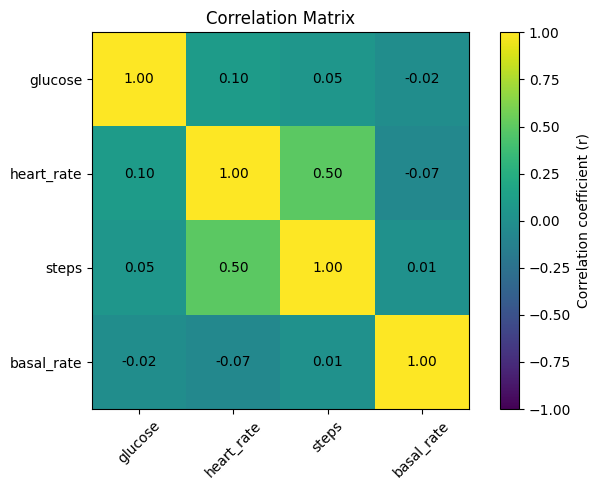

In [72]:
import matplotlib.pyplot as plt

corr = df[["glucose", "heart_rate", "steps", "basal_rate"]].corr()

plt.figure(figsize=(7, 5))

plt.imshow(corr, cmap="viridis", vmin=-1, vmax=1)

plt.colorbar(label="Correlation coefficient (r)")

plt.xticks(range(len(corr.columns)), corr.columns, rotation=45)
plt.yticks(range(len(corr.columns)), corr.columns)

# Add correlation values to each cell
for i in range(len(corr.columns)):
    for j in range(len(corr.columns)):
        plt.text(j, i, f"{corr.iloc[i, j]:.2f}",
                 ha="center", va="center")

plt.title("Correlation Matrix")
plt.tight_layout()
plt.show()

+1 indicates a perfect positive linear relationship.
0 indicates little or no linear relationship.
-1 indicates a perfect negative linear relationship.

Glucose ↔ heart rate: weak positive correlation
Glucose ↔ steps: weak positive correlation
Glucose ↔ basal rate: very weak/slightly positive correlation
Heart rate ↔ steps: noticeably stronger positive correlation
Heart rate ↔ basal rate: very weak/near-zero relationship
Steps ↔ basal rate: very weak positive relationship

#Interpretation

The correlation analysis suggests that glucose has only weak linear associations with heart rate, physical activity (steps), and basal insulin rate in the combined dataset. The strongest visible association is between heart rate and steps, indicating that periods of greater physical activity may be associated with changes in heart rate.

However, correlation alone cannot establish causal relationships. The relatively weak correlations with glucose also suggest that glucose dynamics are influenced by multiple factors rather than a single measured variable.


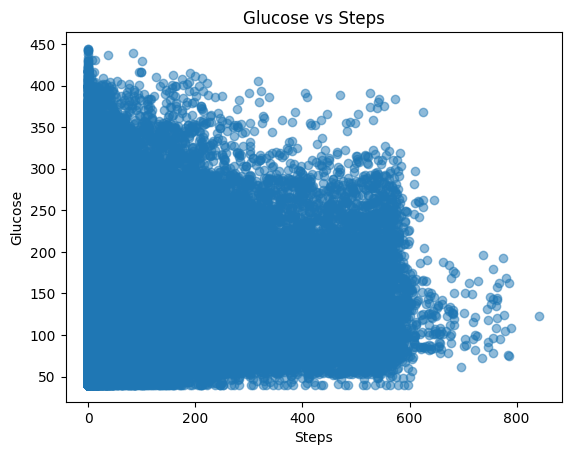

In [73]:
import matplotlib.pyplot as plt
plt.scatter(df["steps"], df["glucose"], alpha=0.5)
plt.xlabel("Steps")
plt.ylabel("Glucose")
plt.title("Glucose vs Steps")
plt.show()

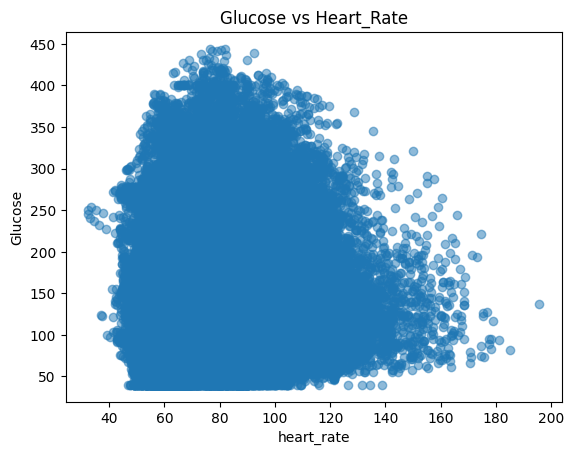

In [74]:
plt.scatter(df["heart_rate"], df["glucose"], alpha=0.5)
plt.xlabel("heart_rate")
plt.ylabel("Glucose")
plt.title("Glucose vs Heart_Rate")
plt.show()

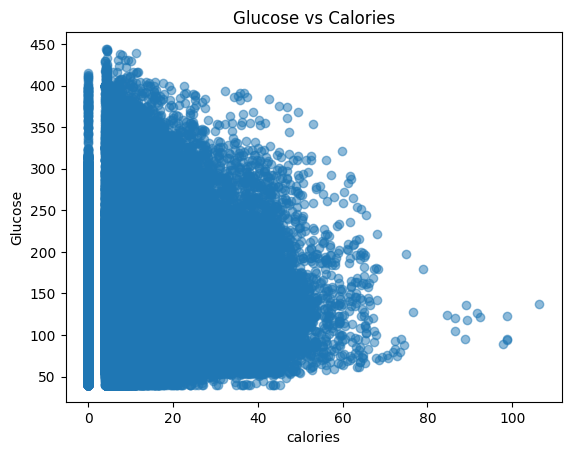

In [75]:
plt.scatter(df["calories"], df["glucose"], alpha=0.5)
plt.xlabel("calories")
plt.ylabel("Glucose")
plt.title("Glucose vs Calories")
plt.show()

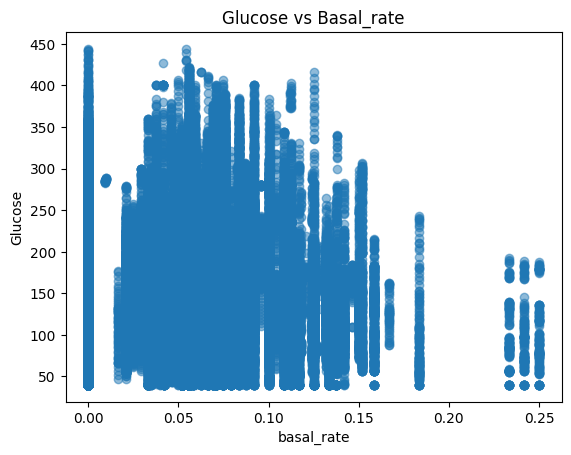

In [76]:
plt.scatter(df["basal_rate"], df["glucose"], alpha=0.5)
plt.xlabel("basal_rate")
plt.ylabel("Glucose")
plt.title("Glucose vs Basal_rate")
plt.show()

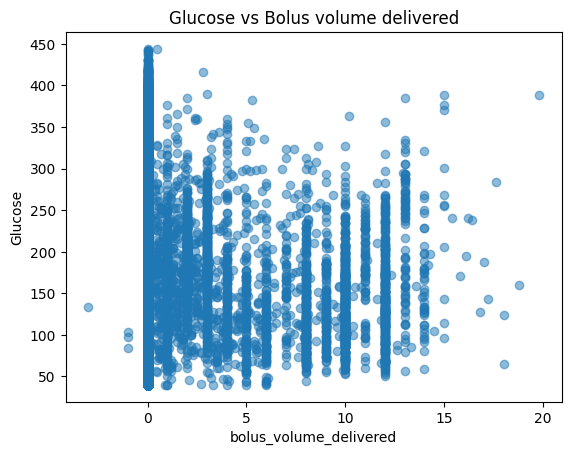

In [77]:
plt.scatter(df["bolus_volume_delivered"], df["glucose"], alpha=0.5)
plt.xlabel("bolus_volume_delivered")
plt.ylabel("Glucose")
plt.title("Glucose vs Bolus volume delivered")
plt.show()

There is no positive or negative realtionship with steps heart rate and calories. 

Q1: 99.66666666666669
Q3: 173.0
IQR: 73.33333333333331


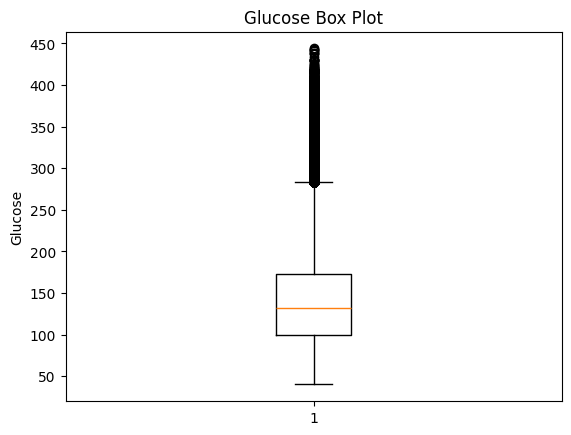

In [78]:
Q1 = df["glucose"].quantile(0.25)
Q3 = df["glucose"].quantile(0.75)

IQR = Q3 - Q1

print("Q1:", Q1)
print("Q3:", Q3)
print("IQR:", IQR)

plt.boxplot(df["glucose"].dropna())
plt.ylabel("Glucose")
plt.title("Glucose Box Plot")
plt.show()

## Participant-Level CGM Analysis

The combined dataset contains CGM measurements from multiple participants. To examine individual-level glucose characteristics, CGM metrics are calculated separately for each participant using the `patient_id` variable.

The following metrics are calculated for each participant:

- Mean glucose
- Standard deviation (SD)
- Minimum glucose
- Maximum glucose
- Coefficient of variation (CV)

In [79]:
import pandas as pd

def calculate_descriptive_metrics(patient_data):
    
    glucose = patient_data["glucose"]
    
    mean_glucose = glucose.mean()
    median_glucose = glucose.median()
    sd_glucose = glucose.std()
    cv = (sd_glucose / mean_glucose) * 100
    
    return pd.Series({
        "Mean Glucose": mean_glucose,
        "Median Glucose": median_glucose,
        "SD": sd_glucose,
        "Min Glucose": glucose.min(),
        "Max Glucose": glucose.max(),
        "CV (%)": cv
    })


patient_summary = df.groupby("patient_id").apply(
    calculate_descriptive_metrics
)

patient_summary

,Mean Glucose,Median Glucose,SD,Min Glucose,Max Glucose,CV (%)
patient_id,,,,,,
HUPA0001P,181.443726,165.666667,70.644633,40.0,444.0,38.934735
HUPA0002P,113.469664,98.666667,59.145068,40.0,310.0,52.124124
HUPA0003P,143.273519,129.000000,61.326542,44.0,366.0,42.803822
HUPA0004P,180.377984,171.666667,83.020747,40.0,411.0,46.025987
HUPA0005P,147.698624,144.000000,49.791133,40.0,379.0,33.711304
HUPA0006P,165.204585,146.000000,84.736079,42.0,438.0,51.291603
HUPA0007P,173.151991,170.333333,78.656646,40.0,385.0,45.426359
HUPA0009P,193.739271,192.000000,46.109890,100.0,307.0,23.799971
HUPA0010P,135.892648,126.000000,57.606632,41.0,416.0,42.391279


In [80]:
def calculate_cgm_metrics(patient_data):
    
    glucose = patient_data["glucose"]
    
    mean_glucose = glucose.mean()
    median_glucose = glucose.median()
    sd_glucose = glucose.std()
    cv = (sd_glucose / mean_glucose) * 100
    
    tir = ((glucose >= 70) & (glucose <= 180)).mean() * 100
    tbr = (glucose < 70).mean() * 100
    tar = (glucose > 180).mean() * 100
    
    return pd.Series({
        "Mean Glucose": mean_glucose,
        "Median Glucose": median_glucose,
        "SD": sd_glucose,
        "CV (%)": cv,
        "Min Glucose": glucose.min(),
        "Max Glucose": glucose.max(),
        "TIR (%)": tir,
        "TBR (%)": tbr,
        "TAR (%)": tar
    })


patient_summary = df.groupby("patient_id").apply(
    calculate_cgm_metrics
)

patient_summary

,Mean Glucose,Median Glucose,SD,CV (%),Min Glucose,Max Glucose,TIR (%),TBR (%),TAR (%)
patient_id,,,,,,,,,
HUPA0001P,181.443726,165.666667,70.644633,38.934735,40.0,444.0,56.494141,1.440430,42.065430
HUPA0002P,113.469664,98.666667,59.145068,52.124124,40.0,310.0,61.490097,23.860421,14.649481
HUPA0003P,143.273519,129.000000,61.326542,42.803822,44.0,366.0,67.665782,7.029178,25.305040
HUPA0004P,180.377984,171.666667,83.020747,46.025987,40.0,411.0,44.817839,9.704774,45.477387
HUPA0005P,147.698624,144.000000,49.791133,33.711304,40.0,379.0,71.824780,2.954899,25.220321
HUPA0006P,165.204585,146.000000,84.736079,51.291603,42.0,438.0,56.026201,8.646288,35.327511
HUPA0007P,173.151991,170.333333,78.656646,45.426359,40.0,385.0,45.864662,8.944776,45.190563
HUPA0009P,193.739271,192.000000,46.109890,23.799971,100.0,307.0,41.448059,0.000000,58.551941
HUPA0010P,135.892648,126.000000,57.606632,42.391279,41.0,416.0,74.831989,8.333333,16.834677


In [81]:
def plot_patient_metric(column, ylabel, title):
    
    plt.figure(figsize=(10, 5))
    
    plt.bar(patient_summary.index, patient_summary[column])
    
    plt.xlabel("Patient ID")
    plt.ylabel(ylabel)
    plt.title(title)
    
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()
  

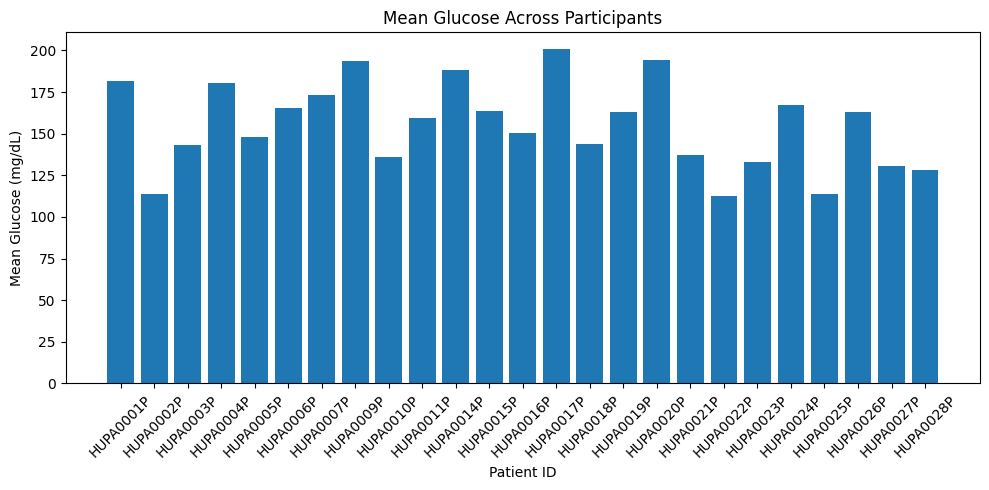

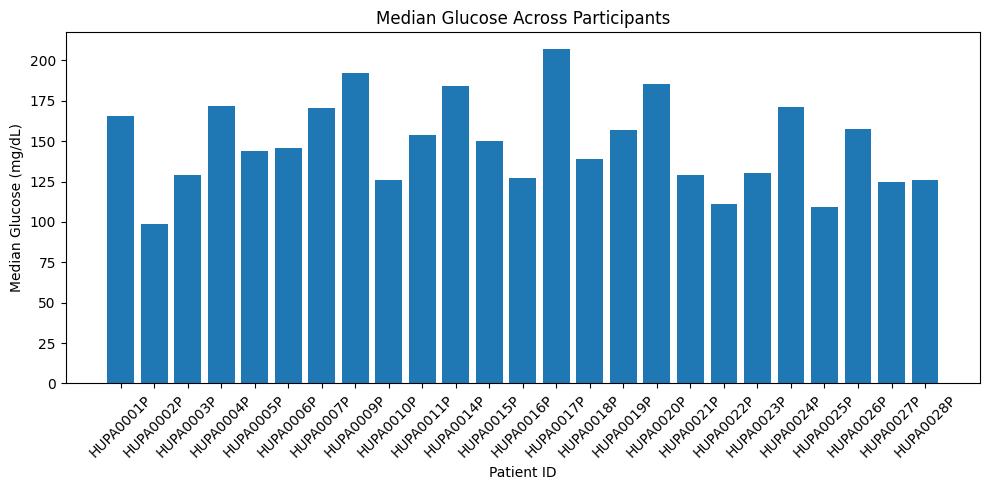

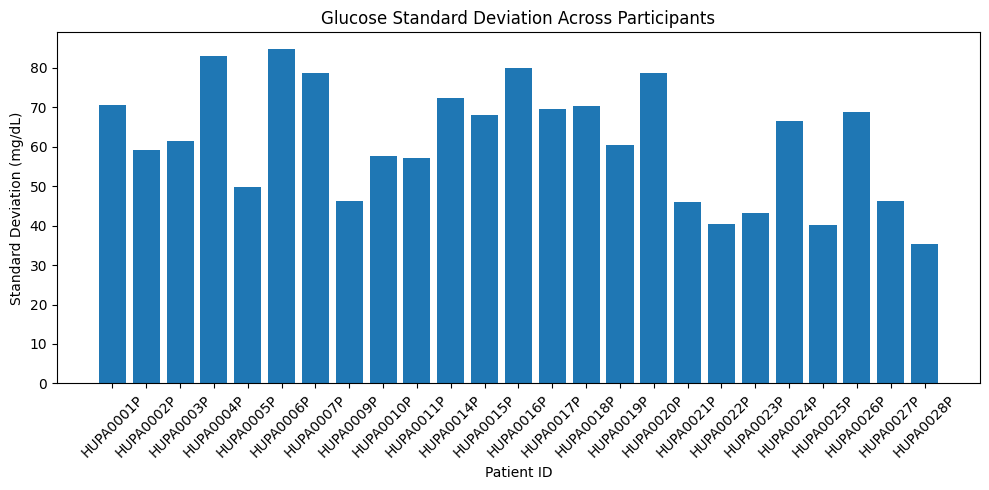

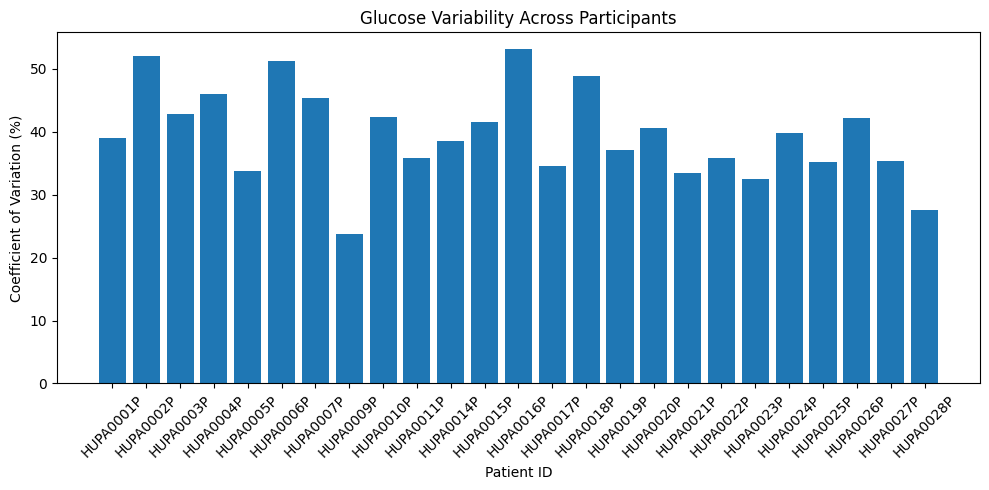

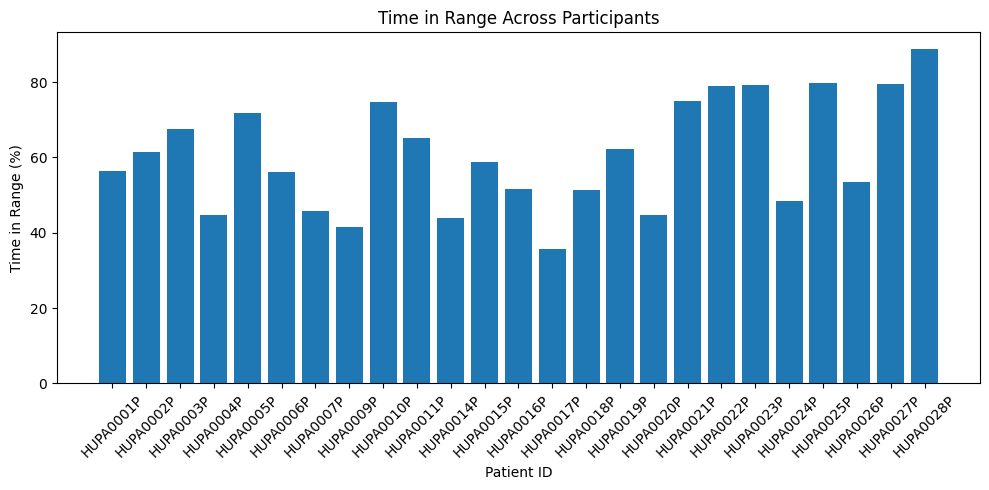

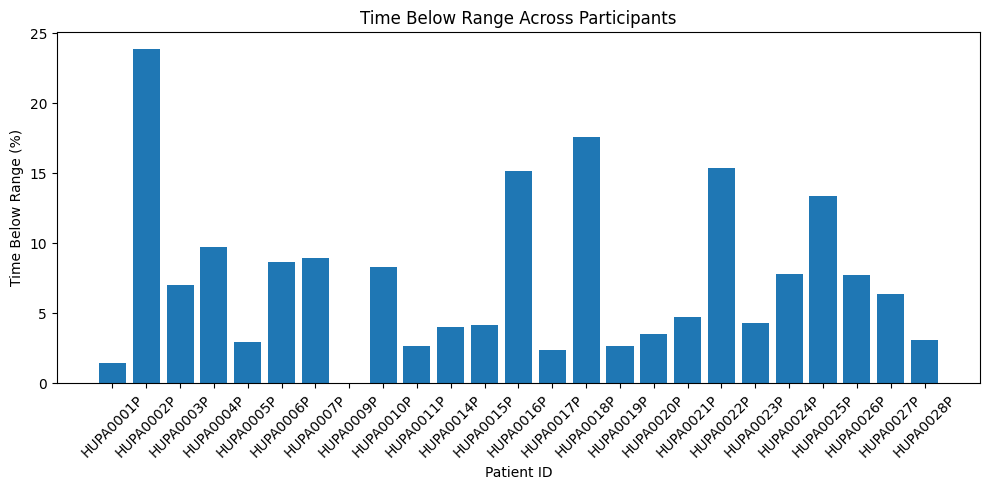

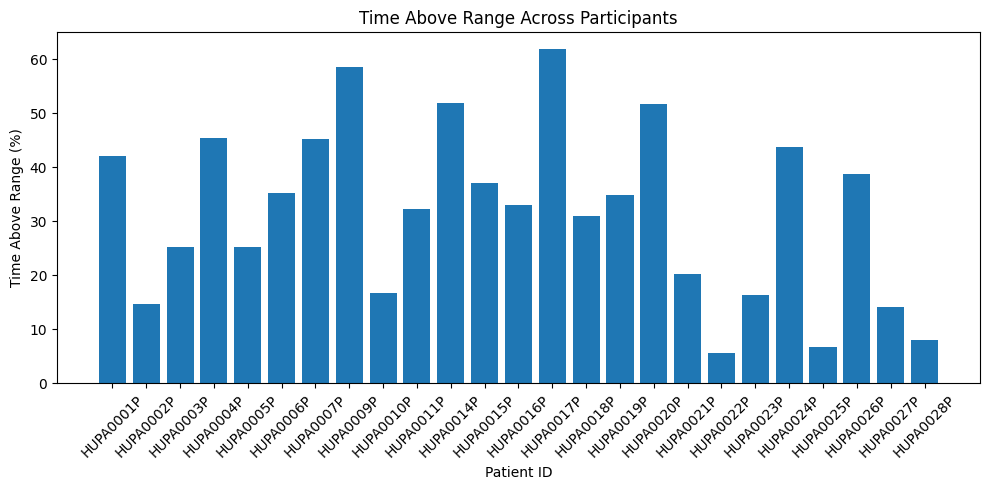

In [82]:
plot_patient_metric(
    "Mean Glucose",
    "Mean Glucose (mg/dL)",
    "Mean Glucose Across Participants"
)

plot_patient_metric(
    "Median Glucose",
    "Median Glucose (mg/dL)",
    "Median Glucose Across Participants"
)

plot_patient_metric(
    "SD",
    "Standard Deviation (mg/dL)",
    "Glucose Standard Deviation Across Participants"
)

plot_patient_metric(
    "CV (%)",
    "Coefficient of Variation (%)",
    "Glucose Variability Across Participants"
)

plot_patient_metric(
    "TIR (%)",
    "Time in Range (%)",
    "Time in Range Across Participants"
)

plot_patient_metric(
    "TBR (%)",
    "Time Below Range (%)",
    "Time Below Range Across Participants"
)

plot_patient_metric(
    "TAR (%)",
    "Time Above Range (%)",
    "Time Above Range Across Participants"
)

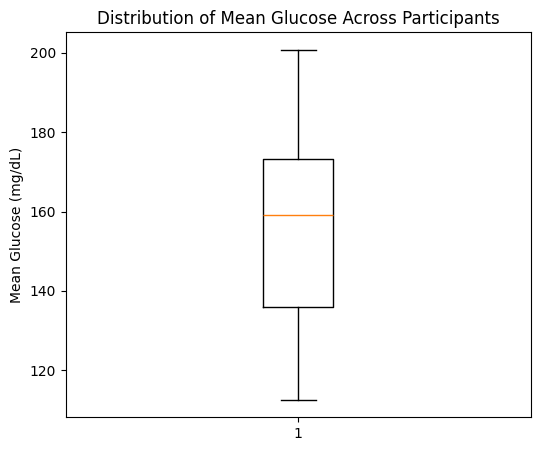

In [83]:
plt.figure(figsize=(6, 5))

plt.boxplot(patient_summary["Mean Glucose"].dropna())

plt.ylabel("Mean Glucose (mg/dL)")
plt.title("Distribution of Mean Glucose Across Participants")

plt.show()

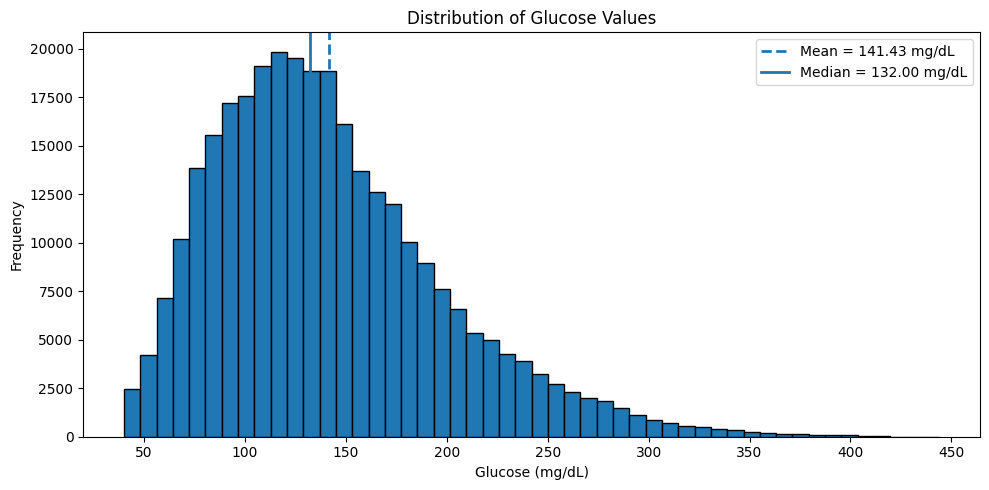

In [84]:
import matplotlib.pyplot as plt

mean_glucose = df["glucose"].mean()
median_glucose = df["glucose"].median()

plt.figure(figsize=(10, 5))

plt.hist(df["glucose"], bins=50, edgecolor="black")

plt.axvline(mean_glucose, linestyle="--", linewidth=2,
            label=f"Mean = {mean_glucose:.2f} mg/dL")

plt.axvline(median_glucose, linestyle="-", linewidth=2,
            label=f"Median = {median_glucose:.2f} mg/dL")

plt.xlabel("Glucose (mg/dL)")
plt.ylabel("Frequency")
plt.title("Distribution of Glucose Values")

plt.legend()
plt.tight_layout()
plt.show()

Mean is higher than median, suggesting higher glucose concentrations shift the mean upward. And the distributuion is right skewed. 

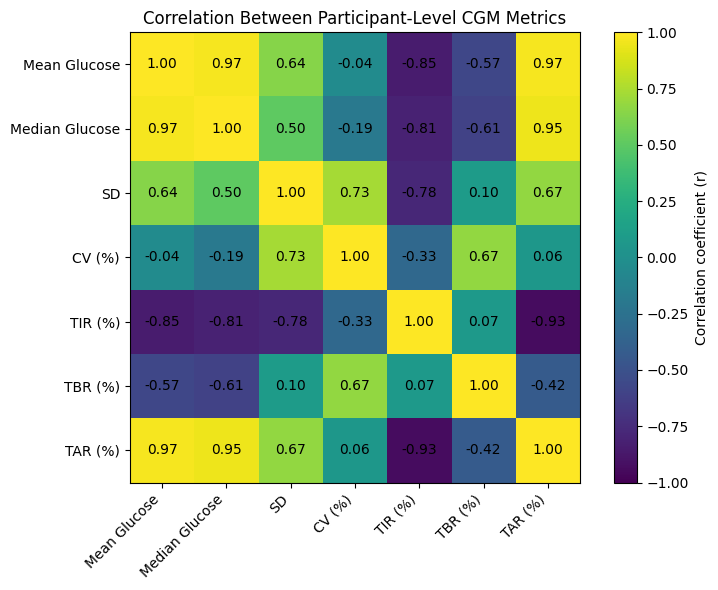

In [85]:
import matplotlib.pyplot as plt

corr = patient_summary[
    ["Mean Glucose", "Median Glucose", "SD", "CV (%)", "TIR (%)", "TBR (%)", "TAR (%)"]
].corr()

plt.figure(figsize=(8, 6))

plt.imshow(corr, cmap="viridis", vmin=-1, vmax=1)

plt.colorbar(label="Correlation coefficient (r)")

plt.xticks(
    range(len(corr.columns)),
    corr.columns,
    rotation=45,
    ha="right"
)

plt.yticks(
    range(len(corr.columns)),
    corr.columns
)

for i in range(len(corr.columns)):
    for j in range(len(corr.columns)):
        plt.text(
            j, i,
            f"{corr.iloc[i, j]:.2f}",
            ha="center",
            va="center"
        )

plt.title("Correlation Between Participant-Level CGM Metrics")
plt.tight_layout()
plt.show()

## Correlation Between Participant-Level CGM Metrics

To investigate relationships between different aspects of glucose control, Pearson correlation coefficients were calculated between participant-level CGM metrics, including mean glucose, median glucose, standard deviation (SD), coefficient of variation (CV), time in range (TIR), time below range (TBR), and time above range (TAR).

The correlation matrix shows a very strong positive correlation between mean glucose and median glucose (r = 0.97), indicating that participants with higher average glucose generally also had higher median glucose values.

Mean glucose showed a strong positive correlation with TAR (r = 0.97) and a strong negative correlation with TIR (r = -0.85). This suggests that participants with higher average glucose tended to spend more time above the target range and less time within the target range.

CV showed almost no linear correlation with mean glucose (r = -0.04). This indicates that average glucose level and relative glucose variability represent different aspects of glycemic behavior. A participant can therefore have a high or low average glucose without necessarily having high or low glucose variability.

SD and CV showed a positive correlation (r = 0.73). This is expected because CV is calculated using SD and mean glucose:

CV = (SD / Mean glucose) × 100

TIR and TAR showed a very strong negative correlation (r = -0.93), which is expected because time spent within range and time spent above range represent different portions of the glucose distribution.

Overall, the correlation analysis demonstrates that average glucose, glucose variability, and time spent within or outside the target range provide different information about glucose behavior and should not be interpreted using a single metric alone.

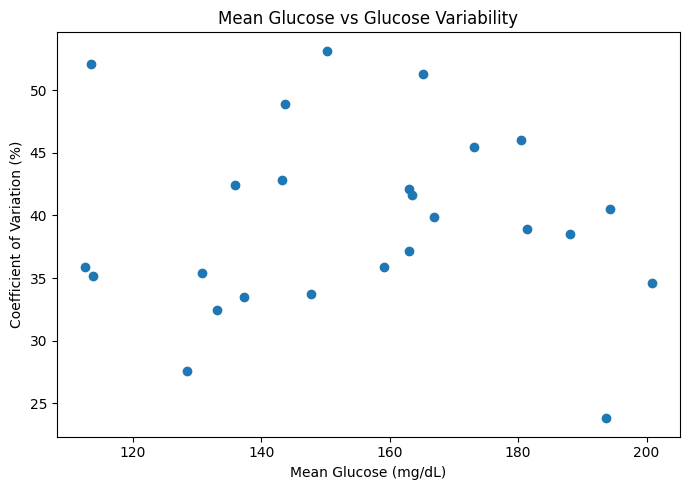

In [86]:
plt.figure(figsize=(7, 5))

plt.scatter(
    patient_summary["Mean Glucose"],
    patient_summary["CV (%)"]
)

plt.xlabel("Mean Glucose (mg/dL)")
plt.ylabel("Coefficient of Variation (%)")
plt.title("Mean Glucose vs Glucose Variability")

plt.tight_layout()
plt.show()

r= -0.04 which is weak linear relationship and can be seen from this

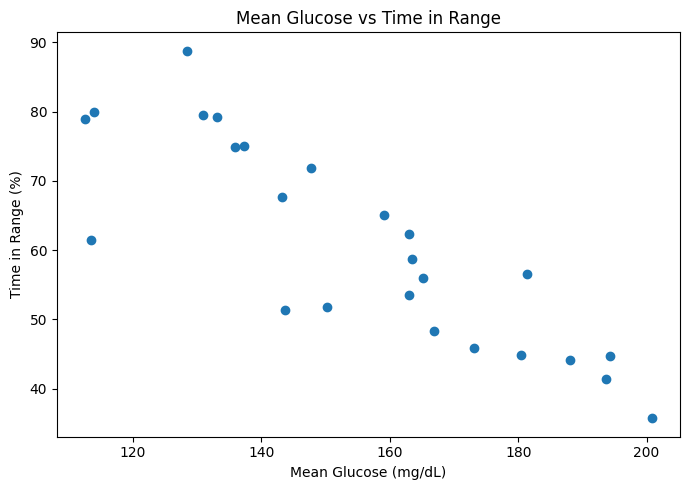

In [87]:
plt.figure(figsize=(7, 5))

plt.scatter(
    patient_summary["Mean Glucose"],
    patient_summary["TIR (%)"]
)

plt.xlabel("Mean Glucose (mg/dL)")
plt.ylabel("Time in Range (%)")
plt.title("Mean Glucose vs Time in Range")

plt.tight_layout()
plt.show()

r= -0.85 it is strong negative relationship, which explains through the scattter plot.
If mean is higher, then TIR will be lower. 

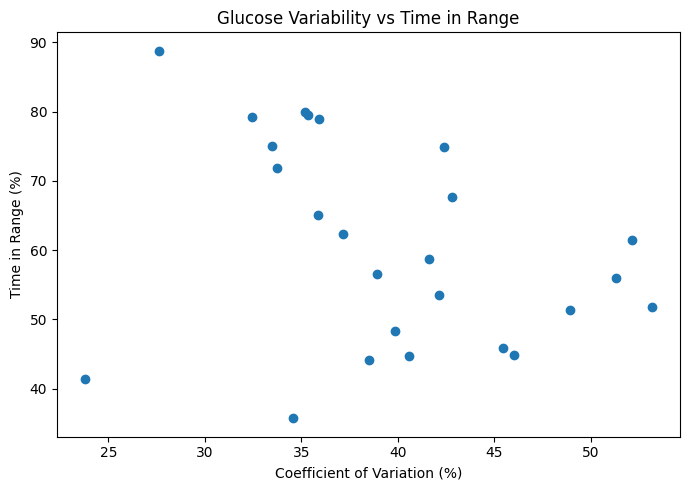

In [88]:
plt.figure(figsize=(7, 5))

plt.scatter(
    patient_summary["CV (%)"],
    patient_summary["TIR (%)"]
)

plt.xlabel("Coefficient of Variation (%)")
plt.ylabel("Time in Range (%)")
plt.title("Glucose Variability vs Time in Range")

plt.tight_layout()
plt.show()

r= -0.33 weak to moderate relationship. If glucose concentrations are above the healthy limit or below, the fluctuations will be higher, so does  the CV.

Single patient Analysis

In [89]:
import pandas as pd

# filepath: f:\cgm-Analyzer\notebooks\cgm.analyser.ipynb
file_path = r"F:\cgm-Analyzer\data\HUPA0001P.csv"

patient = pd.read_csv(file_path, sep=";")

glucose = patient["glucose"]

mean_glucose = glucose.mean()
median_glucose = glucose.median()
sd_glucose = glucose.std()
cv_glucose = (sd_glucose / mean_glucose) * 100

minimum = glucose.min()
maximum = glucose.max()

tir = ((glucose >= 70) & (glucose <= 180)).mean() * 100
tbr = (glucose < 70).mean() * 100
tar = (glucose > 180).mean() * 100

results = pd.DataFrame({
    "Patient": ["HUPA0001P"],
    "Mean": [mean_glucose],
    "Median": [median_glucose],
    "SD": [sd_glucose],
    "CV (%)": [cv_glucose],
    "TIR (%)": [tir],
    "TBR (%)": [tbr],
    "TAR (%)": [tar],
    "Minimum": [minimum],
    "Maximum": [maximum]
})

results


,Patient,Mean,Median,SD,CV (%),TIR (%),TBR (%),TAR (%),Minimum,Maximum
0,HUPA0001P,181.443726,165.666667,70.644633,38.934735,56.494141,1.44043,42.06543,40.0,444.0


In [90]:
patient["time"] = pd.to_datetime(patient["time"])
patient["date"] = patient["time"].dt.date

daily_results = []

for date, day_data in patient.groupby("date"):
    
    glucose = day_data["glucose"]
    
    mean_glucose = glucose.mean()
    median_glucose = glucose.median()
    sd_glucose = glucose.std()
    cv_glucose = (sd_glucose / mean_glucose) * 100
    
    minimum = glucose.min()
    maximum = glucose.max()
    
    tir = ((glucose >= 70) & (glucose <= 180)).mean() * 100
    tbr = (glucose < 70).mean() * 100
    tar = (glucose > 180).mean() * 100
    
    daily_results.append({
        "Date": date,
        "Mean": mean_glucose,
        "Median": median_glucose,
        "SD": sd_glucose,
        "CV (%)": cv_glucose,
        "TIR (%)": tir,
        "TBR (%)": tbr,
        "TAR (%)": tar,
        "Minimum": minimum,
        "Maximum": maximum
    })

daily_results = pd.DataFrame(daily_results)

daily_results

,Date,Mean,Median,SD,CV (%),TIR (%),TBR (%),TAR (%),Minimum,Maximum
0,2018-06-13,169.625000,153.5,79.549226,46.897112,60.937500,7.812500,31.250000,40.0,332.0
1,2018-06-14,155.090278,149.5,53.350842,34.399863,58.333333,6.944444,34.722222,40.0,271.0
2,2018-06-15,167.822917,146.0,64.509213,38.438858,72.569444,0.000000,27.430556,70.0,365.0
3,2018-06-16,155.152778,149.0,41.958875,27.043586,73.263889,1.041667,25.694444,59.0,270.0
4,2018-06-17,160.671875,152.0,45.626046,28.397033,70.486111,0.347222,29.166667,69.0,298.0
5,2018-06-18,158.347222,140.0,55.691637,35.170580,68.055556,0.347222,31.597222,69.0,346.0
6,2018-06-19,161.074653,136.0,77.987741,48.417141,67.013889,1.736111,31.250000,57.0,351.0
7,2018-06-20,185.717014,173.0,71.008919,38.235010,53.472222,0.000000,46.527778,83.0,367.0
8,2018-06-21,217.819444,197.5,84.013543,38.570268,43.055556,0.000000,56.944444,95.0,400.0
9,2018-06-22,205.357639,180.5,82.326770,40.089461,50.000000,0.000000,50.000000,81.0,400.0


Selected June 23 
Highest mean - 240.36
Maximum is 444.0

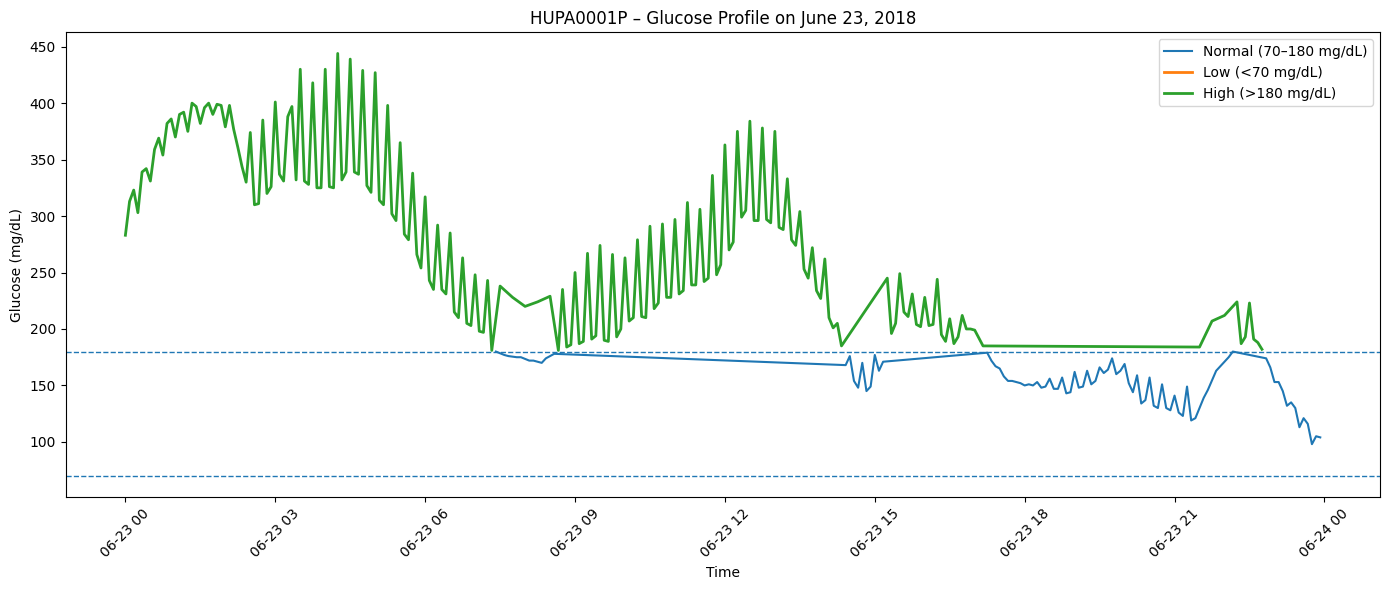

In [91]:
import pandas as pd
import matplotlib.pyplot as plt

# Make sure time is datetime
patient["time"] = pd.to_datetime(patient["time"])

# Select June 23, 2018
june23 = patient[
    patient["time"].dt.date == pd.Timestamp("2018-06-23").date()
].copy()

# Sort by time
june23 = june23.sort_values("time")

# Create masks
low = june23["glucose"] < 70
high = june23["glucose"] > 180
normal = (june23["glucose"] >= 70) & (june23["glucose"] <= 180)

# Plot
plt.figure(figsize=(14, 6))

# Normal glucose
plt.plot(
    june23.loc[normal, "time"],
    june23.loc[normal, "glucose"],
    linewidth=1.5,
    label="Normal (70–180 mg/dL)"
)

# Low glucose
plt.plot(
    june23.loc[low, "time"],
    june23.loc[low, "glucose"],
    linewidth=2,
    label="Low (<70 mg/dL)"
)

# High glucose
plt.plot(
    june23.loc[high, "time"],
    june23.loc[high, "glucose"],
    linewidth=2,
    label="High (>180 mg/dL)"
)

# Reference lines
plt.axhline(70, linestyle="--", linewidth=1)
plt.axhline(180, linestyle="--", linewidth=1)

plt.xlabel("Time")
plt.ylabel("Glucose (mg/dL)")
plt.title("HUPA0001P – Glucose Profile on June 23, 2018")

plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

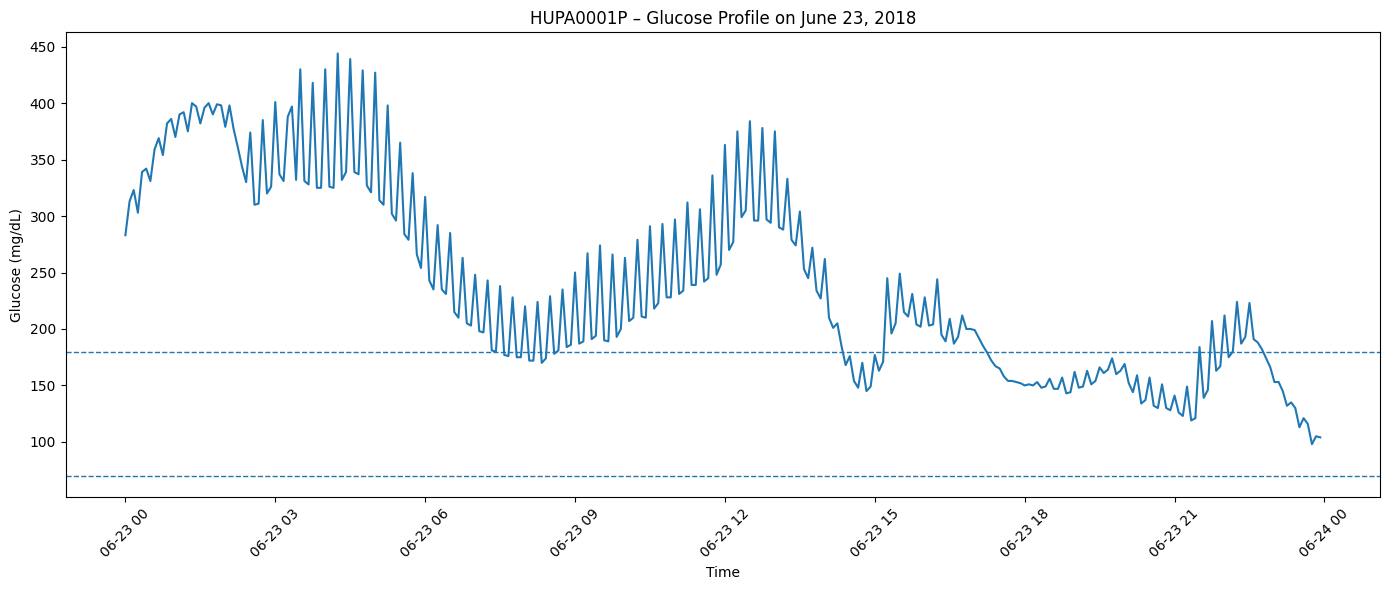

In [92]:
import pandas as pd
import matplotlib.pyplot as plt

# Make sure time is datetime
patient["time"] = pd.to_datetime(patient["time"])

# Select June 23, 2018
june23 = patient[
    patient["time"].dt.date == pd.Timestamp("2018-06-23").date()
].copy()

# Sort by time
june23 = june23.sort_values("time")

# Plot glucose over time
plt.figure(figsize=(14, 6))

plt.plot(
    june23["time"],
    june23["glucose"],
    linewidth=1.5
)

# Reference lines for CGM ranges
plt.axhline(70, linestyle="--", linewidth=1)
plt.axhline(180, linestyle="--", linewidth=1)

plt.xlabel("Time")
plt.ylabel("Glucose (mg/dL)")
plt.title("HUPA0001P – Glucose Profile on June 23, 2018")

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

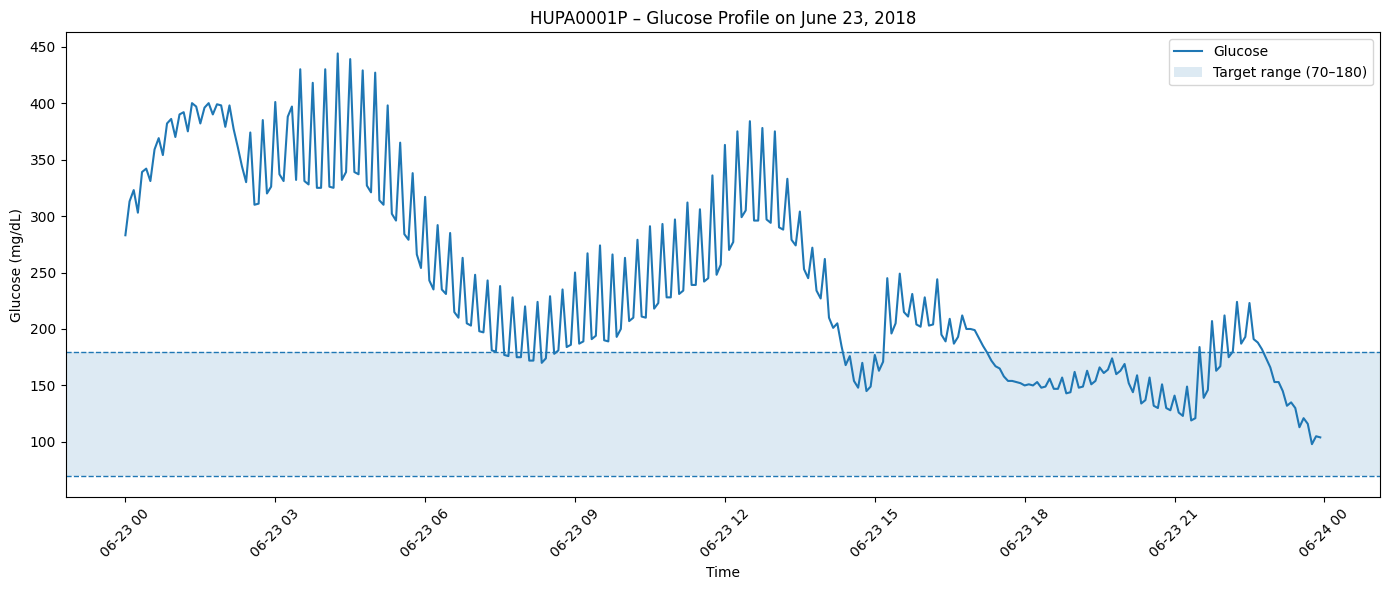

In [93]:
plt.figure(figsize=(14, 6))

plt.plot(
    june23["time"],
    june23["glucose"],
    linewidth=1.5,
    label="Glucose"
)

# Target range
plt.axhspan(70, 180, alpha=0.15, label="Target range (70–180)")

# Thresholds
plt.axhline(70, linestyle="--", linewidth=1)
plt.axhline(180, linestyle="--", linewidth=1)

plt.xlabel("Time")
plt.ylabel("Glucose (mg/dL)")
plt.title("HUPA0001P – Glucose Profile on June 23, 2018")

plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

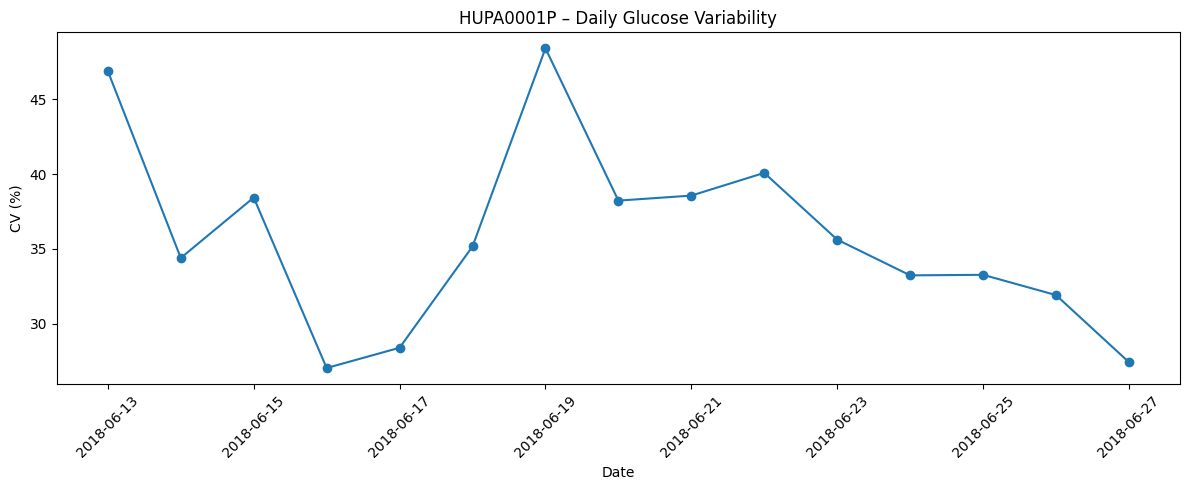

In [94]:
# Daily CV
plt.figure(figsize=(12, 5))

plt.plot(
    daily_results["Date"],
    daily_results["CV (%)"],
    marker="o"
)

plt.xlabel("Date")
plt.ylabel("CV (%)")
plt.title("HUPA0001P – Daily Glucose Variability")

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

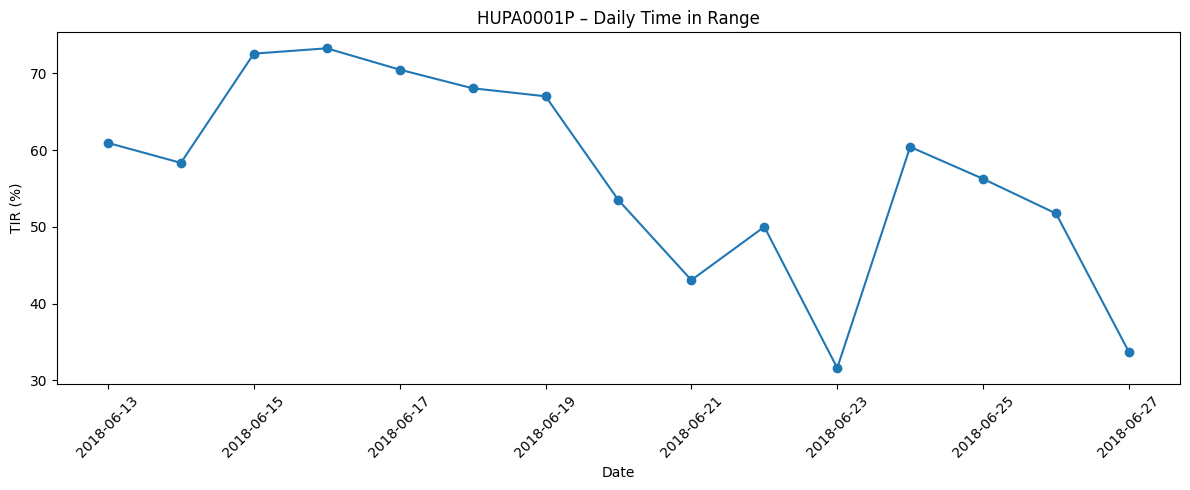

In [95]:
# Daily TIR
plt.figure(figsize=(12, 5))

plt.plot(
    daily_results["Date"],
    daily_results["TIR (%)"],
    marker="o"
)

plt.xlabel("Date")
plt.ylabel("TIR (%)")
plt.title("HUPA0001P – Daily Time in Range")

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

#Event Analysis

In [96]:
june23[june23["carb_input"] > 0][
    ["time", "glucose", "carb_input", "bolus_volume_delivered"]
]

,time,glucose,carb_input,bolus_volume_delivered
2836,2018-06-23 15:00:00,177.0,4.0,5.0


In [97]:
june23[june23["bolus_volume_delivered"] > 0][
    ["time", "glucose", "carb_input", "bolus_volume_delivered"]
]

,time,glucose,carb_input,bolus_volume_delivered
2694,2018-06-23 03:10:00,331.0,0.0,1.5
2707,2018-06-23 04:15:00,444.0,0.0,0.5
2836,2018-06-23 15:00:00,177.0,4.0,5.0


In [98]:
june23[june23["steps"] > 0][
    ["time", "glucose", "steps", "heart_rate"]
]

,time,glucose,steps,heart_rate
2660,2018-06-23 00:20:00,339.0,8.0,79.731707
2695,2018-06-23 03:15:00,388.0,23.0,76.412281
2696,2018-06-23 03:20:00,397.0,8.0,83.770492
2697,2018-06-23 03:25:00,332.0,8.0,70.964912
2708,2018-06-23 04:20:00,332.0,47.0,79.580153
...,...,...,...,...
2927,2018-06-23 22:35:00,191.0,47.0,85.735537
2929,2018-06-23 22:45:00,182.0,109.0,112.638462
2930,2018-06-23 22:50:00,174.0,86.0,98.375000
2931,2018-06-23 22:55:00,166.0,13.0,103.641509


In [99]:
june23["glucose_change"] = june23["glucose"].diff()

june23.nlargest(10, "glucose_change")[
    ["time", "glucose", "glucose_change",
     "carb_input", "bolus_volume_delivered",
     "basal_rate", "steps", "heart_rate", "calories"]
]

,time,glucose,glucose_change,carb_input,bolus_volume_delivered,basal_rate,steps,heart_rate,calories
2707,2018-06-23 04:15:00,444.0,119.0,0.0,0.5,0.054167,0.0,76.336000,4.1055
2716,2018-06-23 05:00:00,427.0,106.0,0.0,0.0,0.041667,0.0,66.686957,4.0250
2800,2018-06-23 12:00:00,363.0,106.0,0.0,0.0,0.037500,46.0,82.087719,9.2575
2704,2018-06-23 04:00:00,430.0,105.0,0.0,0.0,0.054167,0.0,75.113043,4.0250
2710,2018-06-23 04:30:00,439.0,100.0,0.0,0.0,0.054167,83.0,92.425000,11.3505
2698,2018-06-23 03:30:00,430.0,98.0,0.0,0.0,0.054167,0.0,73.781513,4.0250
2803,2018-06-23 12:15:00,375.0,98.0,0.0,0.0,0.037500,45.0,85.981651,10.6260
2713,2018-06-23 04:45:00,429.0,92.0,0.0,0.0,0.054167,101.0,81.583333,9.9820
2797,2018-06-23 11:45:00,336.0,91.0,0.0,0.0,0.037500,4.0,85.779817,7.0035
2701,2018-06-23 03:45:00,418.0,90.0,0.0,0.0,0.054167,0.0,70.066667,4.0250


In [100]:
june23.nsmallest(10, "glucose_change")[
    ["time", "glucose", "glucose_change",
     "carb_input", "bolus_volume_delivered",
     "basal_rate", "steps", "heart_rate", "calories"]
]

,time,glucose,glucose_change,carb_input,bolus_volume_delivered,basal_rate,steps,heart_rate,calories
2717,2018-06-23 05:05:00,314.0,-113.0,0.0,0.0,0.041667,0.0,70.160714,4.1055
2708,2018-06-23 04:20:00,332.0,-112.0,0.0,0.0,0.054167,47.0,79.580153,7.5670
2705,2018-06-23 04:05:00,326.0,-104.0,0.0,0.0,0.054167,0.0,75.109091,4.0250
2714,2018-06-23 04:50:00,327.0,-102.0,0.0,0.0,0.054167,0.0,67.525862,4.1055
2711,2018-06-23 04:35:00,339.0,-100.0,0.0,0.0,0.054167,48.0,105.293103,12.7995
2699,2018-06-23 03:35:00,331.0,-99.0,0.0,0.0,0.054167,0.0,72.836207,4.0250
2720,2018-06-23 05:20:00,302.0,-96.0,0.0,0.0,0.041667,0.0,64.490741,4.0250
2702,2018-06-23 03:50:00,325.0,-93.0,0.0,0.0,0.054167,0.0,71.891667,4.0250
2801,2018-06-23 12:05:00,270.0,-93.0,0.0,0.0,0.037500,17.0,86.574074,7.3255
2798,2018-06-23 11:50:00,248.0,-88.0,0.0,0.0,0.037500,0.0,84.083333,4.1860


When looking at these excursions and drops we cannot see carb input that could possibly affect. Therefore we should not exerct much pressure on that aspect. And only carb input is at 15:00 hours. 

#Examining interesting glucose events

In [ ]:
import matplotlib.pyplot as plt

def plot_cgm_event(event, title):

    fig, axes = plt.subplots(
        6, 1,
        figsize=(14, 16),
        sharex=True
    )

    # 1. GLUCOSE


    axes[0].plot(
        event["time"],
        event["glucose"],
        linewidth=2
    )

    axes[0].axhline(
        180,
        linestyle="--",
        linewidth=1
    )

    axes[0].axhline(
        70,
        linestyle="--",
        linewidth=1
    )

    axes[0].set_ylabel("Glucose\n(mg/dL)")
    axes[0].set_title(title)

    # 2. INSULIN
    

    axes[1].plot(
        event["time"],
        event["basal_rate"],
        linewidth=1.5,
        label="Basal rate"
    )

    bolus = event[
        event["bolus_volume_delivered"] > 0
    ]

    axes[1].scatter(
        bolus["time"],
        bolus["bolus_volume_delivered"],
        s=80,
        marker="v",
        label="Bolus"
    )

    axes[1].set_ylabel("Insulin")
    axes[1].legend()


    # 3. CARBOHYDRATE INPUT
   

    axes[2].bar(
        event["time"],
        event["carb_input"],
        width=0.002
    )

    axes[2].set_ylabel("Carbs\n(g)")

    # 4. STEPS


    axes[3].bar(
        event["time"],
        event["steps"],
        width=0.002
    )

    axes[3].set_ylabel("Steps")

    # 5. HEART RATE

    axes[4].plot(
        event["time"],
        event["heart_rate"],
        linewidth=1.5
    )

    axes[4].set_ylabel("Heart rate\n(bpm)")

   
    # 6. CALORIES
    

    axes[5].plot(
        event["time"],
        event["calories"],
        linewidth=1.5
    )

    axes[5].set_ylabel("Calories")
    axes[5].set_xlabel("Time")


    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

In [106]:
# Event 1: Morning hyperglycemic episode; without any carb input or significant physicalactivity prior to the event. 
# The patient is experiencing a hyperglycemic episode in the morning 04:15, with glucose level of 444 mg/dL. 
# There is no recorded carbohydrate intake or significant physical activity leading up to this event, suggesting that the hyperglycemia may be due to other factors such as hormonal fluctuations, stress, or insufficient insulin delivery. 
# Further investigation into the patient's insulin regimen and potential external factors is recommended to manage and prevent future episodes.

june23["time"] = pd.to_datetime(june23["time"])
event1 = june23[
    (june23["time"] >= "2018-06-23 02:30") &
    (june23["time"] <= "2018-06-23 06:30")
].copy()


event1[
    [
        "time",
        "glucose",
        "carb_input",
        "bolus_volume_delivered",
        "basal_rate",
        "steps",
        "heart_rate",
        "calories"
    ]
]

,time,glucose,carb_input,bolus_volume_delivered,basal_rate,steps,heart_rate,calories
2686,2018-06-23 02:30:00,374.0,0.0,0.0,0.070833,0.0,81.056452,4.1055
2687,2018-06-23 02:35:00,310.0,0.0,0.0,0.070833,0.0,80.616541,4.0250
2688,2018-06-23 02:40:00,311.0,0.0,0.0,0.070833,0.0,80.201493,4.0250
2689,2018-06-23 02:45:00,385.0,0.0,0.0,0.070833,0.0,77.940299,4.0250
2690,2018-06-23 02:50:00,320.0,0.0,0.0,0.070833,0.0,76.279070,4.0250
2691,2018-06-23 02:55:00,326.0,0.0,0.0,0.070833,0.0,77.641509,4.0250
2692,2018-06-23 03:00:00,401.0,0.0,0.0,0.054167,0.0,76.953125,4.0250
2693,2018-06-23 03:05:00,337.0,0.0,0.0,0.054167,0.0,75.133333,4.0250
2694,2018-06-23 03:10:00,331.0,0.0,1.5,0.054167,0.0,75.098592,4.0250
2695,2018-06-23 03:15:00,388.0,0.0,0.0,0.054167,23.0,76.412281,6.6815


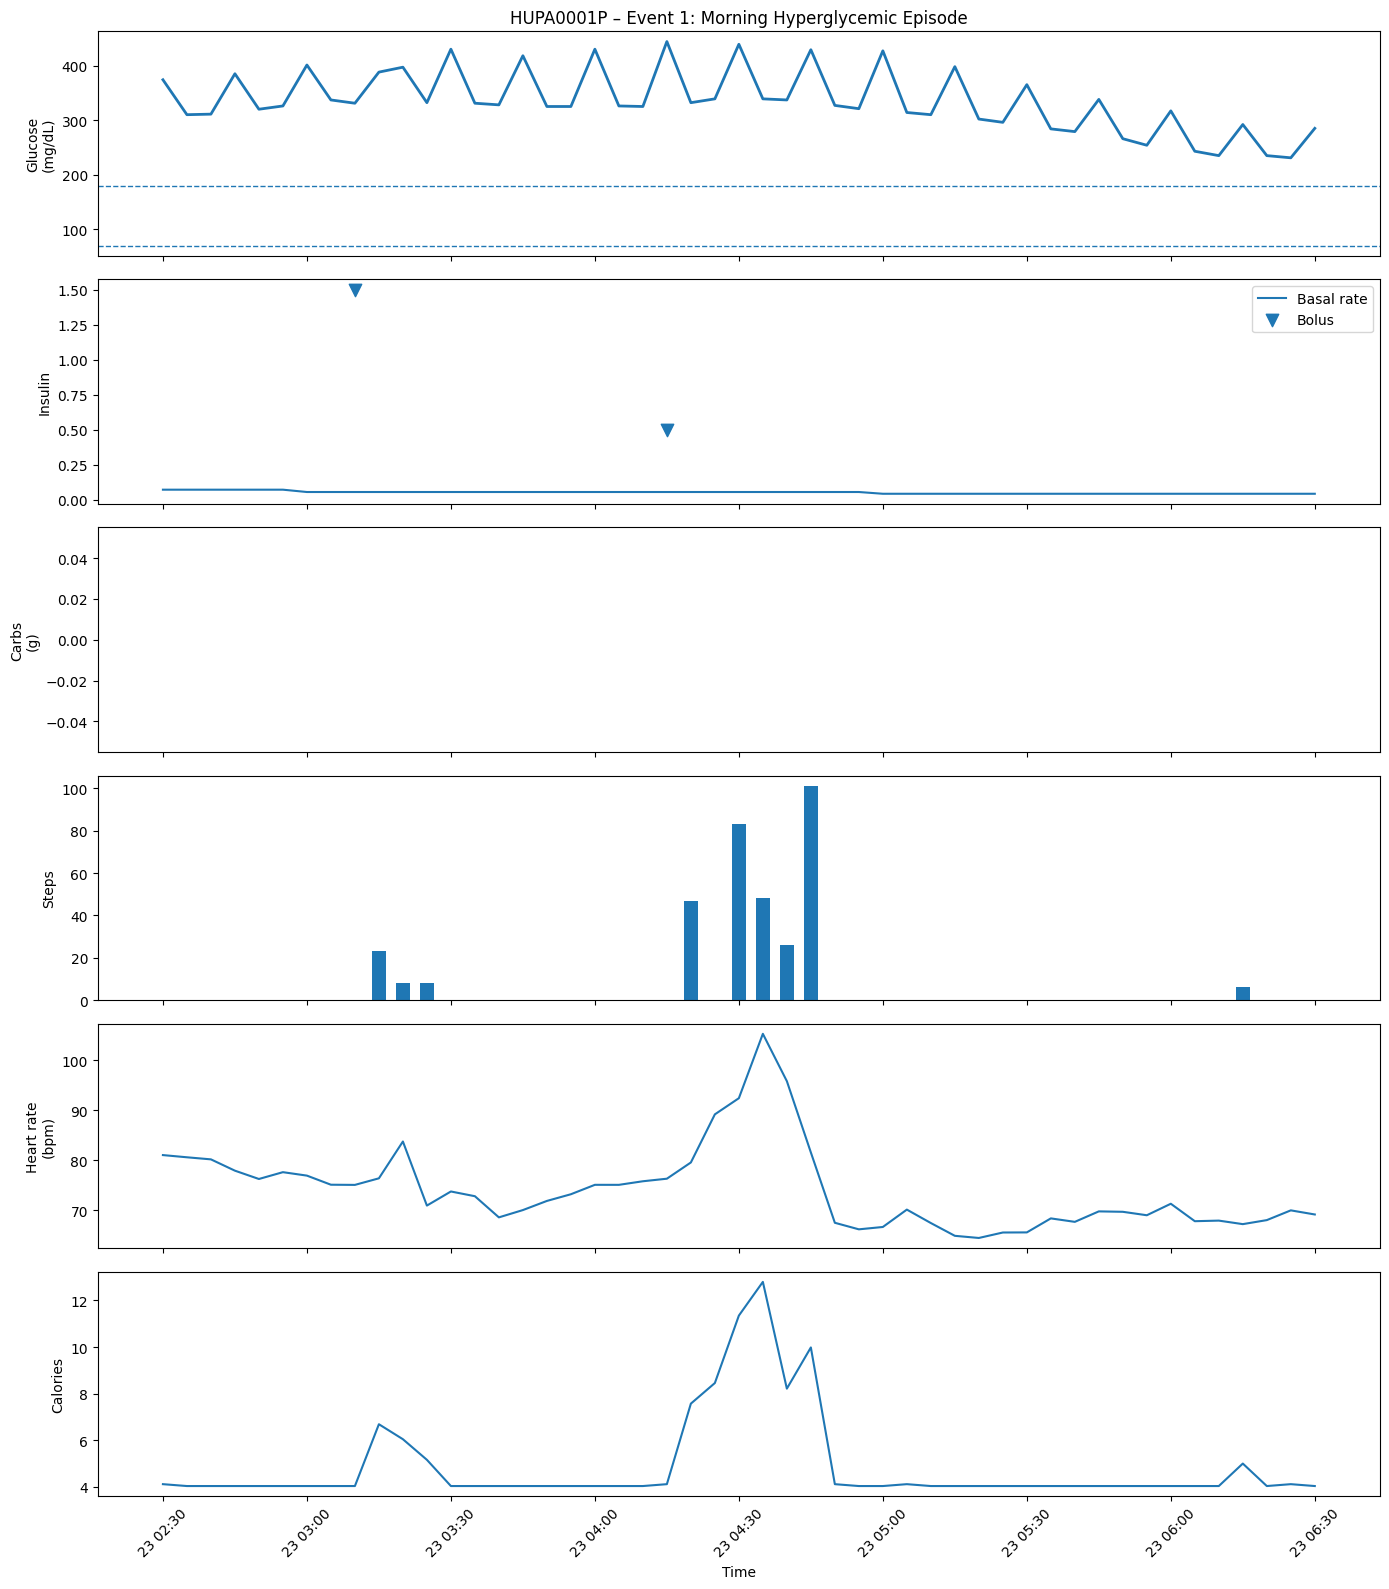

In [107]:
plot_cgm_event(
    event1,
    "HUPA0001P – Event 1: Morning Hyperglycemic Episode"
)

In [104]:
#Event 2: Afternoon hyperglycemic episode; following a meal and bolus insulin administration.


event2 = june23[
    (june23["time"] >= "2018-06-23 14:00") &
    (june23["time"] <= "2018-06-23 17:00")
].copy()

event2[
    [
        "time",
        "glucose",
        "carb_input",
        "bolus_volume_delivered",
        "basal_rate",
        "steps",
        "heart_rate",
        "calories"
    ]
]

,time,glucose,carb_input,bolus_volume_delivered,basal_rate,steps,heart_rate,calories
2824,2018-06-23 14:00:00,262.0,0.0,0.0,0.037500,260.0,107.274194,15.7780
2825,2018-06-23 14:05:00,210.0,0.0,0.0,0.037500,116.0,116.729508,18.8370
2826,2018-06-23 14:10:00,201.0,0.0,0.0,0.037500,251.0,116.075188,20.3665
2827,2018-06-23 14:15:00,205.0,0.0,0.0,0.037500,236.0,92.203252,13.9265
2828,2018-06-23 14:20:00,185.0,0.0,0.0,0.037500,145.0,112.574627,18.1930
2829,2018-06-23 14:25:00,168.0,0.0,0.0,0.037500,61.0,114.149123,17.3075
2830,2018-06-23 14:30:00,176.0,0.0,0.0,0.037500,32.0,97.527132,7.9695
2831,2018-06-23 14:35:00,154.0,0.0,0.0,0.037500,0.0,96.492188,5.2325
2832,2018-06-23 14:40:00,148.0,0.0,0.0,0.037500,11.0,93.486486,9.1770
2833,2018-06-23 14:45:00,170.0,0.0,0.0,0.037500,3.0,90.580357,7.3255


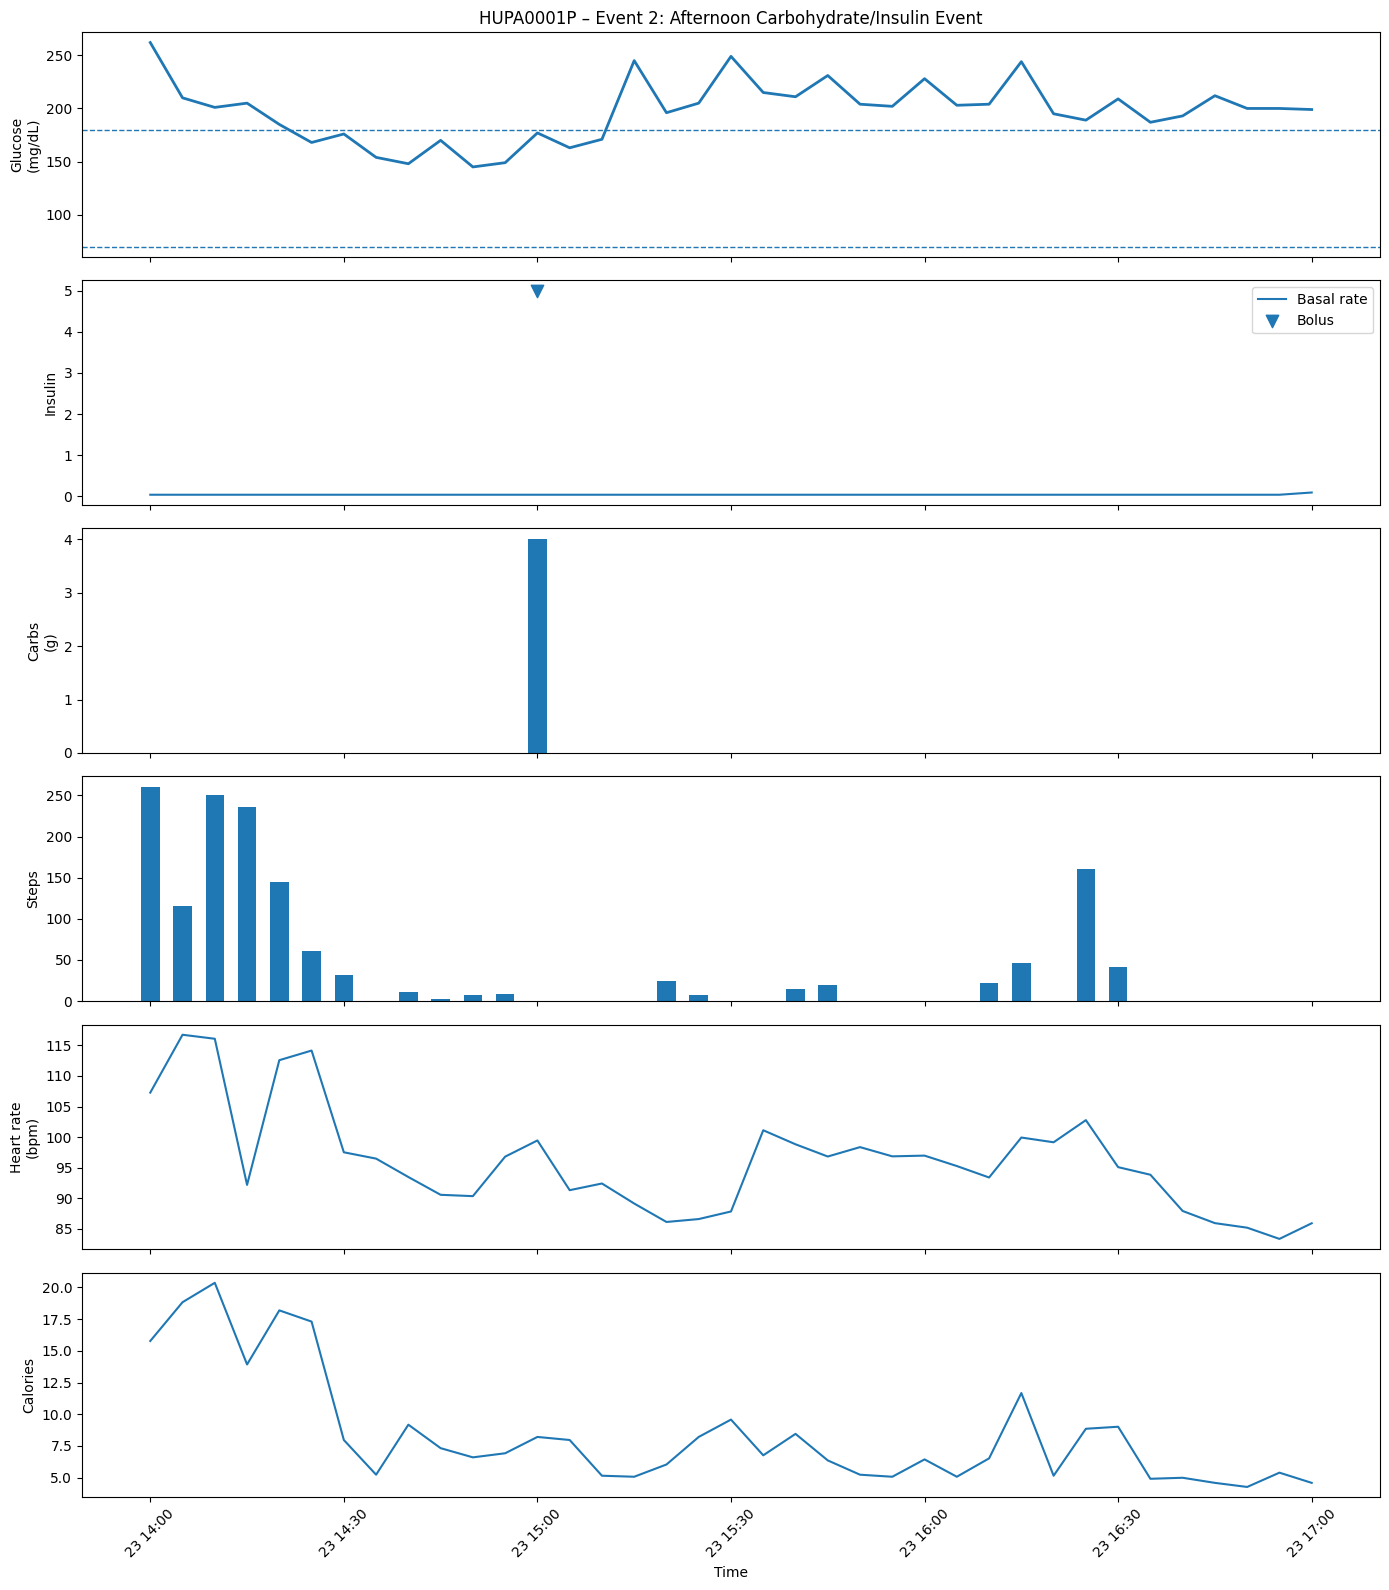

In [108]:
plot_cgm_event(
    event2,
    "HUPA0001P – Event 2: Afternoon Carbohydrate/Insulin Event"
)

In [109]:
event3 = june23[
    (june23["time"] >= "2018-06-23 21:00") &
    (june23["time"] <= "2018-06-23 23:59")
].copy()

event3[
    [
        "time",
        "glucose",
        "carb_input",
        "bolus_volume_delivered",
        "basal_rate",
        "steps",
        "heart_rate",
        "calories"
    ]
]

,time,glucose,carb_input,bolus_volume_delivered,basal_rate,steps,heart_rate,calories
2908,2018-06-23 21:00:00,141.0,0.0,0.0,0.058333,38.0,101.264463,13.5240
2909,2018-06-23 21:05:00,126.0,0.0,0.0,0.058333,43.0,91.623932,9.3380
2910,2018-06-23 21:10:00,123.0,0.0,0.0,0.058333,10.0,91.150442,6.6010
2911,2018-06-23 21:15:00,149.0,0.0,0.0,0.058333,6.0,98.117647,9.7405
2912,2018-06-23 21:20:00,119.0,0.0,0.0,0.058333,0.0,84.461538,4.7495
2913,2018-06-23 21:25:00,121.0,0.0,0.0,0.058333,0.0,86.956140,4.9105
2914,2018-06-23 21:30:00,184.0,0.0,0.0,0.058333,137.0,88.902655,10.4650
2915,2018-06-23 21:35:00,139.0,0.0,0.0,0.058333,54.0,94.205128,10.5455
2916,2018-06-23 21:40:00,146.0,0.0,0.0,0.058333,0.0,89.297521,6.3595
2917,2018-06-23 21:45:00,207.0,0.0,0.0,0.058333,0.0,87.692308,5.0715


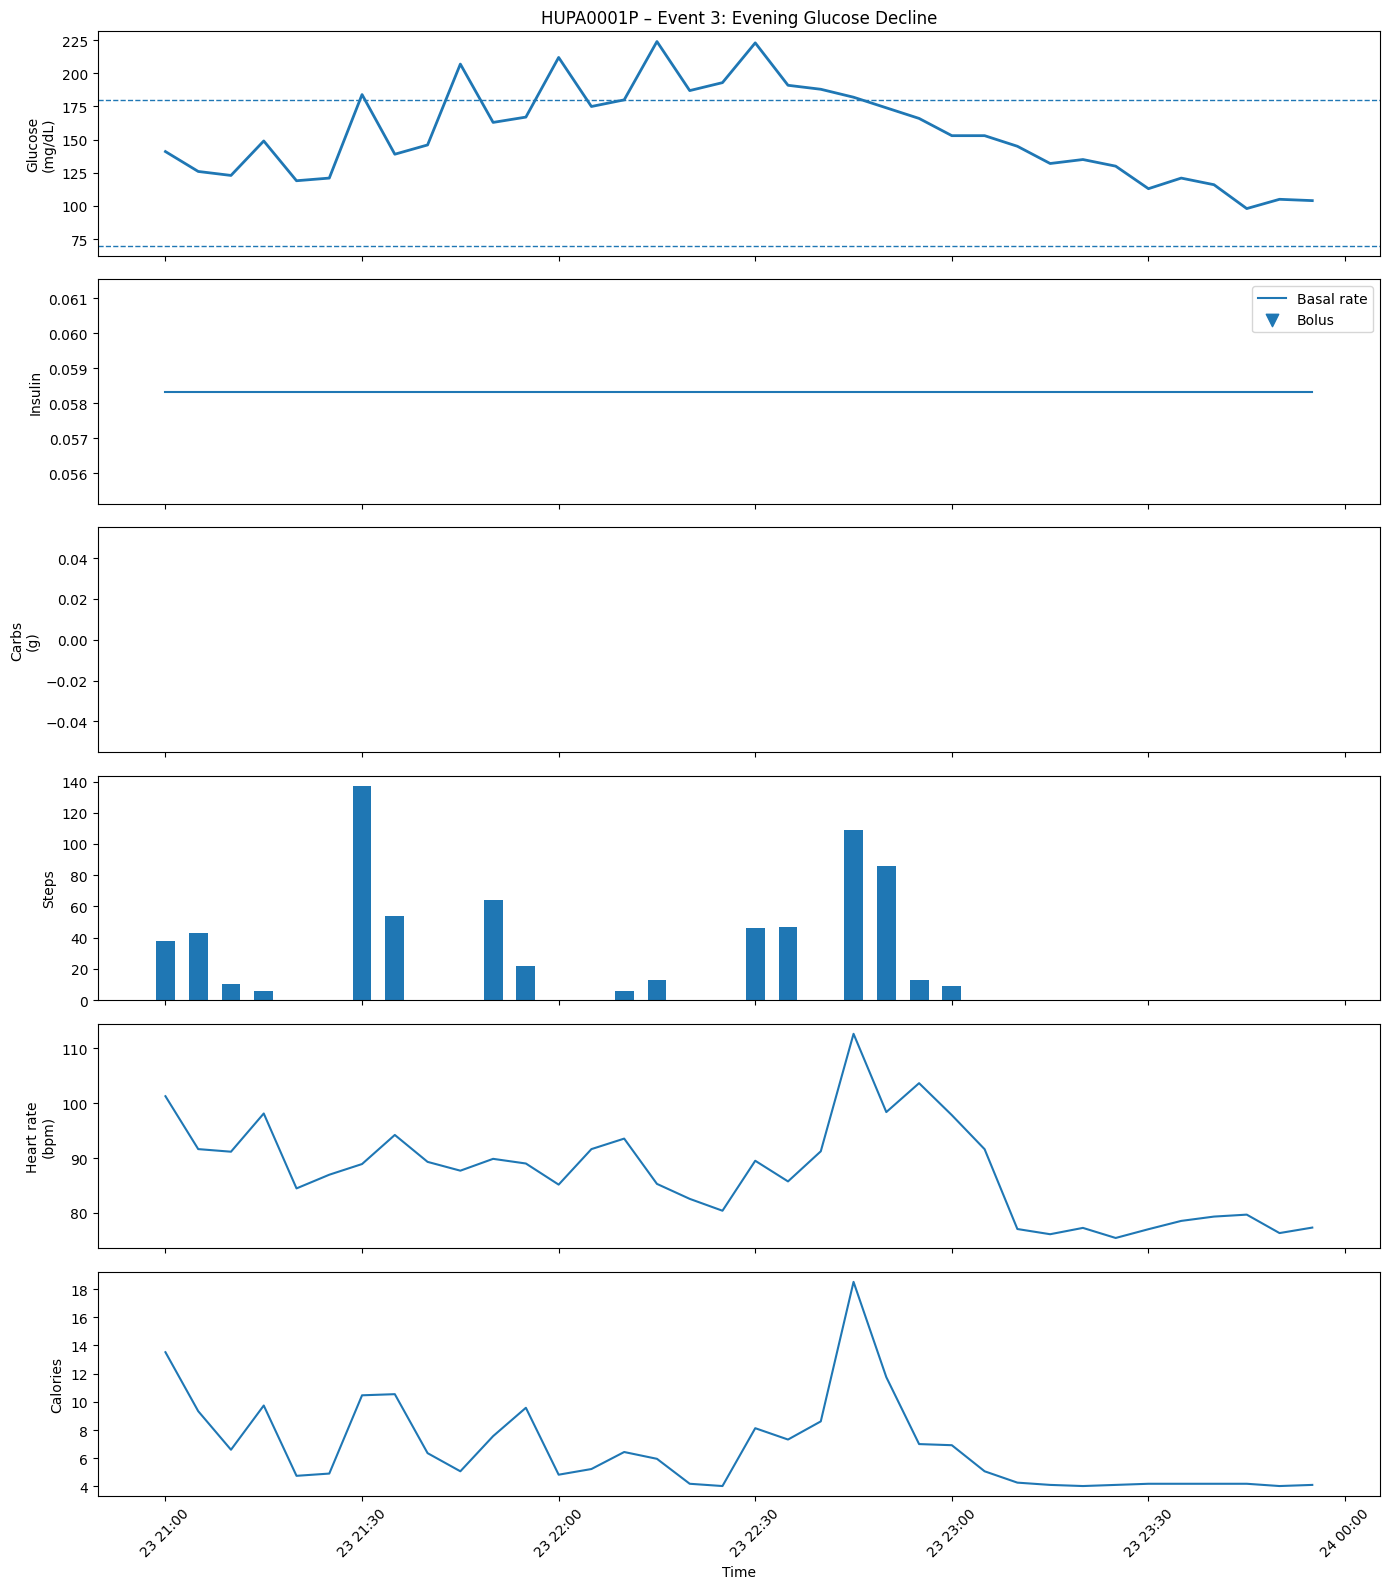

In [110]:
plot_cgm_event(
    event3,
    "HUPA0001P – Event 3: Evening Glucose Decline"
)

Descriptive Analysis

In [113]:
def analyze_event(data, start_time, end_time, event_name):
    
    event = data[
        (data["time"] >= start_time) &
        (data["time"] <= end_time)
    ].copy()

    # Starting glucose
    start_glucose = event.iloc[0]["glucose"]

    # Peak glucose
    peak_idx = event["glucose"].idxmax()
    peak_glucose = event.loc[peak_idx, "glucose"]
    peak_time = event.loc[peak_idx, "time"]

    # Minimum glucose
    min_idx = event["glucose"].idxmin()
    min_glucose = event.loc[min_idx, "glucose"]
    min_time = event.loc[min_idx, "time"]

    # Change
    glucose_change = peak_glucose - start_glucose

    # Event variables
    total_carbs = event["carb_input"].sum()
    total_bolus = event["bolus_volume_delivered"].sum()
    total_steps = event["steps"].sum()
    max_hr = event["heart_rate"].max()
    total_calories = event["calories"].sum()

    return {
        "Event": event_name,
        "Start glucose": start_glucose,
        "Peak glucose": peak_glucose,
        "Peak time": peak_time,
        "Minimum glucose": min_glucose,
        "Minimum time": min_time,
        "Glucose change": glucose_change,
        "Carbs (g)": total_carbs,
        "Bolus (U)": total_bolus,
        "Steps": total_steps,
        "Max HR": max_hr,
        "Calories": total_calories
    }

In [115]:
event1 = analyze_event(
    june23,
    "2018-06-23 02:30",
    "2018-06-23 06:30",
    "Morning hyperglycemia"
)
event2 = analyze_event(
    june23,
    "2018-06-23 13:00",
    "2018-06-23 18:00",
    "Afternoon carbohydrate + insulin"
)

event3 = analyze_event(
    june23,
    "2018-06-23 22:00",
    "2018-06-23 23:30",
    "Evening glucose decline"
)


In [116]:
event_results = pd.DataFrame([
    event1,
    event2,
    event3
])

event_results

,Event,Start glucose,Peak glucose,Peak time,Minimum glucose,Minimum time,Glucose change,Carbs (g),Bolus (U),Steps,Max HR,Calories
0,Morning hyperglycemia,374.0,444.0,2018-06-23 04:15:00,231.0,2018-06-23 06:25:00,70.0,0.0,2.0,350.0,105.293103,238.602001
1,Afternoon carbohydrate + insulin,375.0,375.0,2018-06-23 13:00:00,145.0,2018-06-23 14:50:00,0.0,4.0,5.0,2408.0,116.729508,487.185998
2,Evening glucose decline,212.0,224.0,2018-06-23 22:15:00,113.0,2018-06-23 23:30:00,12.0,0.0,0.0,329.0,112.638462,124.694499


#Repeating for Other patients

In [117]:
import pandas as pd
import glob
import os

# Folder containing all patient CSV files
files = glob.glob(r"F:\cgm-Analyzer\data\*.csv")

# Store daily results from ALL patients
all_daily_results = []

# Loop through every patient file
for file in files:

    # -----------------------------
    # Load patient data
    # -----------------------------
    patient = pd.read_csv(file, sep=";")

    # Convert time to datetime
    patient["time"] = pd.to_datetime(patient["time"])

    # Get patient ID from filename
    patient_id = os.path.splitext(os.path.basename(file))[0]

    # Create date column
    patient["date"] = patient["time"].dt.date

    # -----------------------------
    # Daily analysis
    # -----------------------------
    daily_results = []

    for date, day in patient.groupby("date"):

        glucose = day["glucose"]

        # Descriptive statistics
        mean_glucose = glucose.mean()
        median_glucose = glucose.median()
        sd_glucose = glucose.std()

        # Coefficient of variation
        cv_glucose = (sd_glucose / mean_glucose) * 100

        # CGM metrics
        tir = ((glucose >= 70) & (glucose <= 180)).mean() * 100
        tbr = (glucose < 70).mean() * 100
        tar = (glucose > 180).mean() * 100

        # Minimum and maximum
        minimum = glucose.min()
        maximum = glucose.max()

        # Store daily results
        daily_results.append({
            "Patient": patient_id,
            "Date": date,
            "Mean": mean_glucose,
            "Median": median_glucose,
            "SD": sd_glucose,
            "CV (%)": cv_glucose,
            "TIR (%)": tir,
            "TBR (%)": tbr,
            "TAR (%)": tar,
            "Minimum": minimum,
            "Maximum": maximum
        })

    # Convert this patient's results to DataFrame
    daily_results = pd.DataFrame(daily_results)

    # Add this patient's results to the overall list
    all_daily_results.append(daily_results)


# --------------------------------
# Combine ALL patients
# --------------------------------
all_daily_results = pd.concat(
    all_daily_results,
    ignore_index=True
)

# Display result
all_daily_results

,Patient,Date,Mean,Median,SD,CV (%),TIR (%),TBR (%),TAR (%),Minimum,Maximum
0,HUPA0001P,2018-06-13,169.625000,153.500000,79.549226,46.897112,60.937500,7.812500,31.250000,40.000000,332.0
1,HUPA0001P,2018-06-14,155.090278,149.500000,53.350842,34.399863,58.333333,6.944444,34.722222,40.000000,271.0
2,HUPA0001P,2018-06-15,167.822917,146.000000,64.509213,38.438858,72.569444,0.000000,27.430556,70.000000,365.0
3,HUPA0001P,2018-06-16,155.152778,149.000000,41.958875,27.043586,73.263889,1.041667,25.694444,59.000000,270.0
4,HUPA0001P,2018-06-17,160.671875,152.000000,45.626046,28.397033,70.486111,0.347222,29.166667,69.000000,298.0
...,...,...,...,...,...,...,...,...,...,...,...
1088,HUPA0028P,2022-05-14,128.250000,131.500000,43.610605,34.004371,71.527778,13.194444,15.277778,60.000000,208.0
1089,HUPA0028P,2022-05-15,148.748264,145.000000,47.590314,31.993862,66.319444,5.902778,27.777778,59.000000,267.0
1090,HUPA0028P,2022-05-16,143.142361,144.000000,24.500606,17.116251,93.750000,0.000000,6.250000,87.000000,218.0
1091,HUPA0028P,2022-05-17,161.776357,157.000000,43.802842,27.076170,68.055556,1.388889,30.555556,61.000000,256.0


# Interesting days
Definition
Criterion	        Meaning
High TAR	        A lot of the day was above 180 mg/dL
Low TIR	            Little time was in the target range
High TBR	        More time below 70 mg/dL
High CV	             High glucose variability
High mean	        Overall glucose was unusually high

Cannot conclude they are clinically abnormal, nevertheless they need further inspection
Each of above condition gets a +1 mark, the days that have more marks will selected as important days

In [119]:
# ----------------------------------------
# Find important days across all patients
# ----------------------------------------

important_days = all_daily_results.copy()

# Reset index so that the row numbers are continuous
important_days = important_days.reset_index(drop=True)

# Start score at zero
important_days["Interesting Score"] = 0

# Number of days to consider for each criterion
top_n = 3


# ----------------------------------------
# 1. Highest TAR
# ----------------------------------------

for patient_id, group in important_days.groupby("Patient"):

    indices = group.nlargest(top_n, "TAR (%)").index

    important_days.loc[indices, "Interesting Score"] += 1


# ----------------------------------------
# 2. Lowest TIR
# ----------------------------------------

for patient_id, group in important_days.groupby("Patient"):

    indices = group.nsmallest(top_n, "TIR (%)").index

    important_days.loc[indices, "Interesting Score"] += 1


# ----------------------------------------
# 3. Highest TBR
# ----------------------------------------

for patient_id, group in important_days.groupby("Patient"):

    indices = group.nlargest(top_n, "TBR (%)").index

    important_days.loc[indices, "Interesting Score"] += 1


# ----------------------------------------
# 4. Highest CV
# ----------------------------------------

for patient_id, group in important_days.groupby("Patient"):

    indices = group.nlargest(top_n, "CV (%)").index

    important_days.loc[indices, "Interesting Score"] += 1


# ----------------------------------------
# 5. Highest Mean glucose
# ----------------------------------------

for patient_id, group in important_days.groupby("Patient"):

    indices = group.nlargest(top_n, "Mean").index

    important_days.loc[indices, "Interesting Score"] += 1


# ----------------------------------------
# NOW filter important days
# ----------------------------------------

important_days = important_days[
    important_days["Interesting Score"] >= 2
].copy()


# Reset index again
important_days = important_days.reset_index(drop=True)


# Display
important_days

,Patient,Date,Mean,Median,SD,CV (%),TIR (%),TBR (%),TAR (%),Minimum,Maximum,Interesting Score
0,HUPA0001P,2018-06-13,169.625000,153.500000,79.549226,46.897112,60.937500,7.812500,31.250000,40.000000,332.0,2
1,HUPA0001P,2018-06-21,217.819444,197.500000,84.013543,38.570268,43.055556,0.000000,56.944444,95.000000,400.0,3
2,HUPA0001P,2018-06-23,240.368056,216.500000,85.634687,35.626484,31.597222,0.000000,68.402778,98.000000,444.0,3
3,HUPA0001P,2018-06-27,219.059028,227.000000,60.092327,27.432025,33.680556,0.000000,66.319444,116.000000,333.0,3
4,HUPA0002P,2018-06-14,78.946181,71.333333,40.878919,51.780744,47.916667,49.305556,2.777778,40.000000,221.0,2
...,...,...,...,...,...,...,...,...,...,...,...,...
105,HUPA0027P,2020-10-30,213.492254,217.833333,61.571419,28.840119,23.263889,0.694444,76.041667,60.500000,298.0,2
106,HUPA0027P,2021-08-31,57.298036,56.573248,4.438369,7.746110,2.777778,97.222222,0.000000,51.000000,78.0,2
107,HUPA0028P,2022-04-26,119.423611,95.000000,68.693252,57.520662,32.291667,38.541667,29.166667,40.000000,260.0,3
108,HUPA0028P,2022-05-02,174.322917,172.333333,28.678957,16.451628,56.250000,0.000000,43.750000,82.666667,258.0,3


#Detecting events 
Event	                     Simple rule
Hyperglycemia	           Glucose > 180 mg/dL for a sustained period
Hypoglycemia	           Glucose < 70 mg/dL for a sustained period
Rapid rise	               Glucose increases substantially within a short period
Rapid fall              	Glucose decreases substantially within a short period

thresholds and minimum limits
1.Hyperglycemia 
>180 mg/dL
for ≥30 minutes
2.Hypoglucemia
<70 mg/dL
for ≥15 minutes
3.Rapid riseincrease ≥50 mg/dL
within 60 minutes
4.Rapid Fall
decrease ≥50 mg/dL
within 60 minutes
